# shared_buffers sweep — how buffer size (and indexing) change tpch

This notebook is separate from `testPlot.ipynb`. It analyses the
**`logs/shared_buffers/`** sweep on the server: the same tpch workload
(pg 18.4, 53 queries) run at several **`shared_buffers`** sizes
(`sb_128MB`, `sb_512MB`, `sb_1GB`, `sb_4GB`), each on the **base** schema and
on the **indexed** schema (`_idx`). The two variables under study are therefore:

* **shared_buffers** — the size of Postgres' buffer cache;
* **index status** — base vs indexed.

A cohort here is `(shared_buffers | index_status)`. The first figure mirrors the
main per-query plot from `testPlot`; everything after it is specific to what a
buffer-size sweep is actually *for* — cache hit rate, disk reads, and where more
buffers (or an index) actually buy you runtime and energy.

## 1. Fetch the shared_buffers logs → local `sb_cache/`

Walks `logs/shared_buffers/sb_*/`, downloads every `query_timing_*` /
`query_samples_*` pair (base and `_idx`), and mirrors them into a **new**
local cache folder `sb_cache/` (kept separate from `testPlot`'s `csv_cache/`).
On a failed fetch it falls back to that cache.

In [1]:
# %pip install paramiko pandas matplotlib
import io, re, time
from pathlib import Path
import numpy as np
import pandas as pd
import paramiko

SSH_HOST = "192.168.1.42"
SSH_USER = "user01"
SSH_PASS = "a"                       # demo credential
REMOTE_SB = "/home/user01/GreenSQL/logs/shared_buffers"
CACHE_DIR = Path("sb_cache")         # new cache, separate from csv_cache/
RETRIES = 5

# file suffix -> index status
VARIANTS = {"tpch": "base", "tpch_idx": "idx"}


def sb_to_mb(name):
    m = re.match(r"sb_(\d+)(MB|GB)$", str(name))
    if not m:
        return None
    v = int(m.group(1))
    return v * 1024 if m.group(2) == "GB" else v


def sb_label(mb):
    return f"{mb // 1024} GB" if mb >= 1024 and mb % 1024 == 0 else f"{mb} MB"


def fetch_over_ssh():
    last = None
    for attempt in range(1, RETRIES + 1):
        try:
            cl = paramiko.SSHClient()
            cl.set_missing_host_key_policy(paramiko.AutoAddPolicy())
            cl.connect(SSH_HOST, username=SSH_USER, password=SSH_PASS,
                       timeout=45, banner_timeout=45, auth_timeout=45)
            try:
                with cl.open_sftp() as sftp:
                    blobs = {}
                    for sb in sftp.listdir(REMOTE_SB):
                        if sb_to_mb(sb) is None:
                            continue
                        d = f"{REMOTE_SB}/{sb}"
                        try:
                            here = set(sftp.listdir(d))
                        except IOError:
                            continue
                        for suf in VARIANTS:
                            for kind in ("timing", "samples"):
                                fn = f"query_{kind}_{suf}.csv"
                                if fn in here:
                                    blobs[f"{sb}/{fn}"] = sftp.open(f"{d}/{fn}").read()
                    if not blobs:
                        raise RuntimeError(f"no CSVs under {REMOTE_SB}")
                    return blobs
            finally:
                cl.close()
        except Exception as exc:
            last = exc
            print(f"  attempt {attempt}/{RETRIES} failed: {type(exc).__name__}")
            time.sleep(3)
    raise RuntimeError(f"SSH failed after {RETRIES} attempts: {last}")


def load():
    try:
        blobs = fetch_over_ssh()
        CACHE_DIR.mkdir(parents=True, exist_ok=True)
        for rel, b in blobs.items():
            p = CACHE_DIR / rel
            p.parent.mkdir(parents=True, exist_ok=True)
            p.write_bytes(b)
        print(f"Fetched shared_buffers logs from {SSH_HOST}; "
              f"cache '{CACHE_DIR}/' updated.")
        return blobs, "server"
    except Exception as exc:
        if not CACHE_DIR.exists():
            raise RuntimeError(f"{exc}\nNo cache at '{CACHE_DIR}/'.") from exc
        blobs = {p.relative_to(CACHE_DIR).as_posix(): p.read_bytes()
                 for p in CACHE_DIR.rglob("*.csv")}
        if not blobs:
            raise RuntimeError(f"{exc}\nCache '{CACHE_DIR}/' is empty.") from exc
        age_h = (time.time() - max((CACHE_DIR / r).stat().st_mtime
                                   for r in blobs)) / 3600
        print(f"\n!! {exc}")
        print(f"!! Falling back to cache '{CACHE_DIR}/' ({age_h:.1f} h old).\n")
        return blobs, "cache"


BLOBS, SOURCE = load()
sbs = sorted({sb_to_mb(rel.split('/')[0]) for rel in BLOBS})
print(f"source: {SOURCE};  {len(BLOBS)} files;  "
      f"shared_buffers sizes: {[sb_label(m) for m in sbs]}")

Fetched shared_buffers logs from 192.168.1.42; cache 'sb_cache/' updated.
source: server;  20 files;  shared_buffers sizes: ['128 MB', '512 MB', '1 GB', '4 GB', '8 GB']


## 2. Build per-query data (timing + samples), keyed by `(shared_buffers, index)`

Each `(shared_buffers, index)` directory is one **cohort**. The batched timing
file is reduced to per-execution numbers exactly like `testPlot` (mean of the
measured batches' `avg_copy_elapsed_sec`, `rapl_pkg_j / batchnum`, …), and the
per-copy samples file adds the server planning/execution split and the
**buffer counters** — `shared_hit_blks`, `shared_read_blks` — that a
shared_buffers study lives on.

In [2]:
def query_group(q):
    return re.sub(r"^queries/", "", str(q)).rsplit("/", 1)[0]


parts_t, parts_s = [], []
for rel, b in BLOBS.items():
    sbname, fn = rel.split("/", 1)
    mb = sb_to_mb(sbname)
    idx = "idx" if "_idx" in fn else "base"
    df = pd.read_csv(io.BytesIO(b))
    df["sb_mb"] = mb
    df["sb_label"] = sb_label(mb)
    df["index_status"] = idx
    df["cohort"] = df["sb_label"] + " | " + idx
    (parts_t if "timing" in fn else parts_s).append(df)

timing = pd.concat(parts_t, ignore_index=True)
samples = pd.concat(parts_s, ignore_index=True)
KEY = ["cohort", "query"]

# ---- timing -> per-execution ----
mt = timing[timing["phase"] == "measured"].copy()
for c in ["batchnum", "elapsed_sec", "avg_copy_elapsed_sec", "server_sum_ms",
          "client_overhead_sec", "rapl_pkg_j", "rapl_core_j", "failed"]:
    mt[c] = pd.to_numeric(mt[c], errors="coerce")
mt = mt[mt["failed"].fillna(0) == 0]
bn = mt["batchnum"].replace(0, np.nan)
mt["copy_time"] = mt["avg_copy_elapsed_sec"]
mt["copy_pkg"] = mt["rapl_pkg_j"] / bn
mt["copy_core"] = mt["rapl_core_j"] / bn
mt["copy_overhead"] = mt["client_overhead_sec"] / bn
mt["copy_server"] = (mt["server_sum_ms"] / 1000.0) / bn
for c in ["copy_pkg", "copy_core"]:            # RAPL overflow -> N/A
    mt[c] = mt[c].mask(mt[c] < 0)

tim = mt.groupby(KEY, as_index=False).agg(
    n_batches=("batch_index", "size"),
    avg_time_s=("copy_time", "mean"), time_std=("copy_time", "std"),
    time_min=("copy_time", "min"), time_max=("copy_time", "max"),
    avg_pkg_j=("copy_pkg", "mean"), pkg_j_std=("copy_pkg", "std"),
    avg_core_j=("copy_core", "mean"), core_j_std=("copy_core", "std"),
    server_s=("copy_server", "mean"), overhead_s=("copy_overhead", "mean"),
    sb_mb=("sb_mb", "first"), sb_label=("sb_label", "first"),
    index_status=("index_status", "first"),
)
tim["time_mean"] = tim["avg_time_s"]
tim["sql_file"] = tim["query"].astype(str).str.split("/").str[-1]
tim["group"] = tim["query"].map(query_group)
tim["qid"] = tim["query"].astype(str).str.replace(
    r"^queries/tpch/tpch-queries/", "", regex=True)

# ---- samples -> server split + buffer counters ----
meas = samples[samples["phase"] == "measured"].copy()
for c in ["server_planning_ms", "server_execution_ms", "shared_hit_blks",
          "shared_read_blks", "temp_read_blks", "temp_written_blks",
          "rows_processed", "bytes_processed"]:
    if c in meas.columns:
        meas[c] = pd.to_numeric(meas[c], errors="coerce")
smp = meas.groupby(KEY).agg(
    plan_ms=("server_planning_ms", "mean"), exec_ms=("server_execution_ms", "mean"),
    shared_hit=("shared_hit_blks", "mean"), shared_read=("shared_read_blks", "mean"),
    temp_read=("temp_read_blks", "mean"), temp_written=("temp_written_blks", "mean"),
    rows_processed=("rows_processed", "mean"),
    bytes_processed=("bytes_processed", "mean"),
)
smp["plan_ratio"] = smp["plan_ms"] / (smp["plan_ms"] + smp["exec_ms"]).replace(0, np.nan)
blks = (smp["shared_hit"] + smp["shared_read"]).replace(0, np.nan)
smp["cache_hit_pct"] = 100 * smp["shared_hit"] / blks
smp["read_mb"] = smp["shared_read"] * 8 / 1024.0        # 8 KB blocks -> MB
smp["temp_blks"] = smp["temp_read"] + smp["temp_written"]

data = tim.merge(smp.reset_index(), on=KEY, how="left")
r = data["plan_ratio"].fillna(0.0)
data["plan_s"] = data["server_s"] * r
data["exec_s"] = data["server_s"] * (1.0 - r)
data["cv_pct"] = 100 * data["time_std"] / data["avg_time_s"]
data["power_w"] = data["avg_pkg_j"] / data["avg_time_s"]
data["label"] = data["sql_file"]

SB_ALL = sorted(data["sb_mb"].dropna().unique())
IDX_ALL = [s for s in ["base", "idx"] if s in set(data["index_status"])]
print(f"{len(data)} (cohort, query) rows; {data['qid'].nunique()} queries; "
      f"{data['group'].nunique()} query folders")
print(f"shared_buffers: {[sb_label(m) for m in SB_ALL]}; index: {IDX_ALL}")
print(data.groupby(['sb_label', 'index_status']).agg(
    queries=('qid', 'nunique'),
    total_runtime_s=('avg_time_s', 'sum'),
    median_cache_hit=('cache_hit_pct', 'median')).round(2).to_string())

530 (cohort, query) rows; 53 queries; 21 query folders
shared_buffers: ['128 MB', '512 MB', '1 GB', '4 GB', '8 GB']; index: ['base', 'idx']
                       queries  total_runtime_s  median_cache_hit
sb_label index_status                                            
1 GB     base               53           141.23            100.00
         idx                53            32.24            100.00
128 MB   base               53           231.31             53.05
         idx                53            53.66             68.95
4 GB     base               53           138.26            100.00
         idx                53            30.11            100.00
512 MB   base               53           159.18             79.29
         idx                53            39.50             84.14
8 GB     base               53           140.76            100.00
         idx                53            29.90            100.00


## 3. Main per-query plots (like testPlot), one figure per tpch query folder

One figure per query folder (`q01`, `q02`, …); within it every variant
(`base.sql`, `v1_materialized.sql`, …) is shown once per cohort. Bars are the
stacked sub-timing (planning → execution → client overhead) with ±1 std
whiskers, then package and core energy.

Each bar's label is **`variant [shared_buffers | index]`**. **Indexed** bars
are hatched (`xx`); bars are ordered by shared_buffers so the buffer trend
reads left-to-right within each variant. Figures are split into **runtime
bins** so small and large queries keep their own scale.

21 query folder(s) -> 25 figures


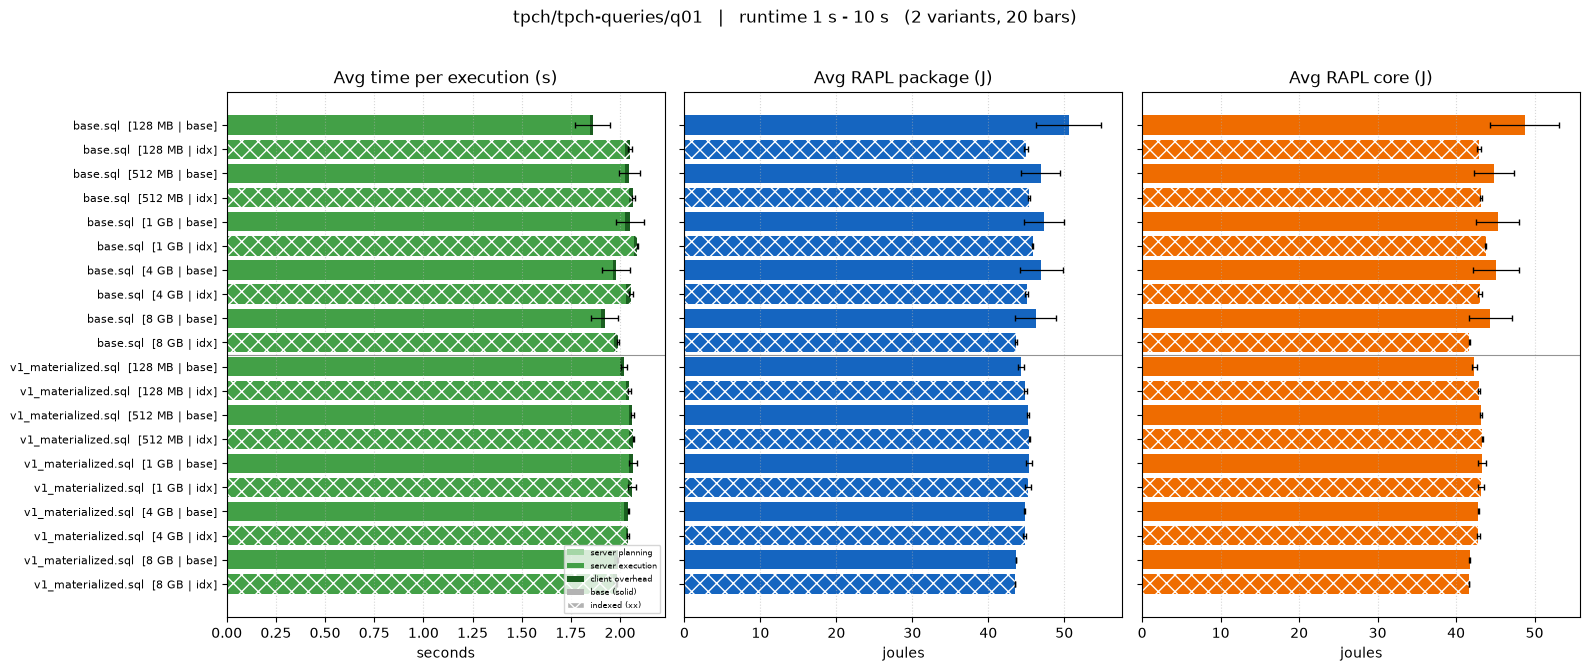

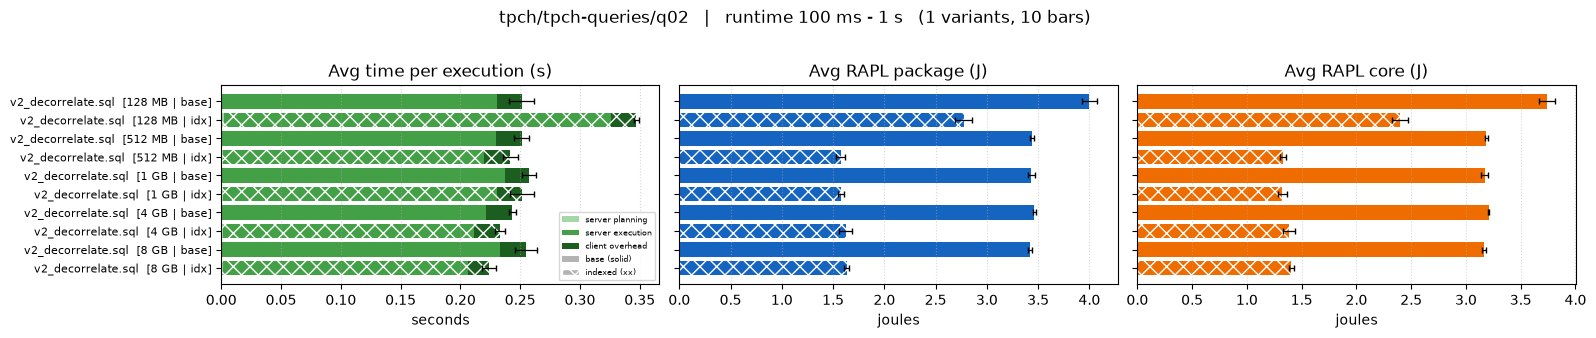

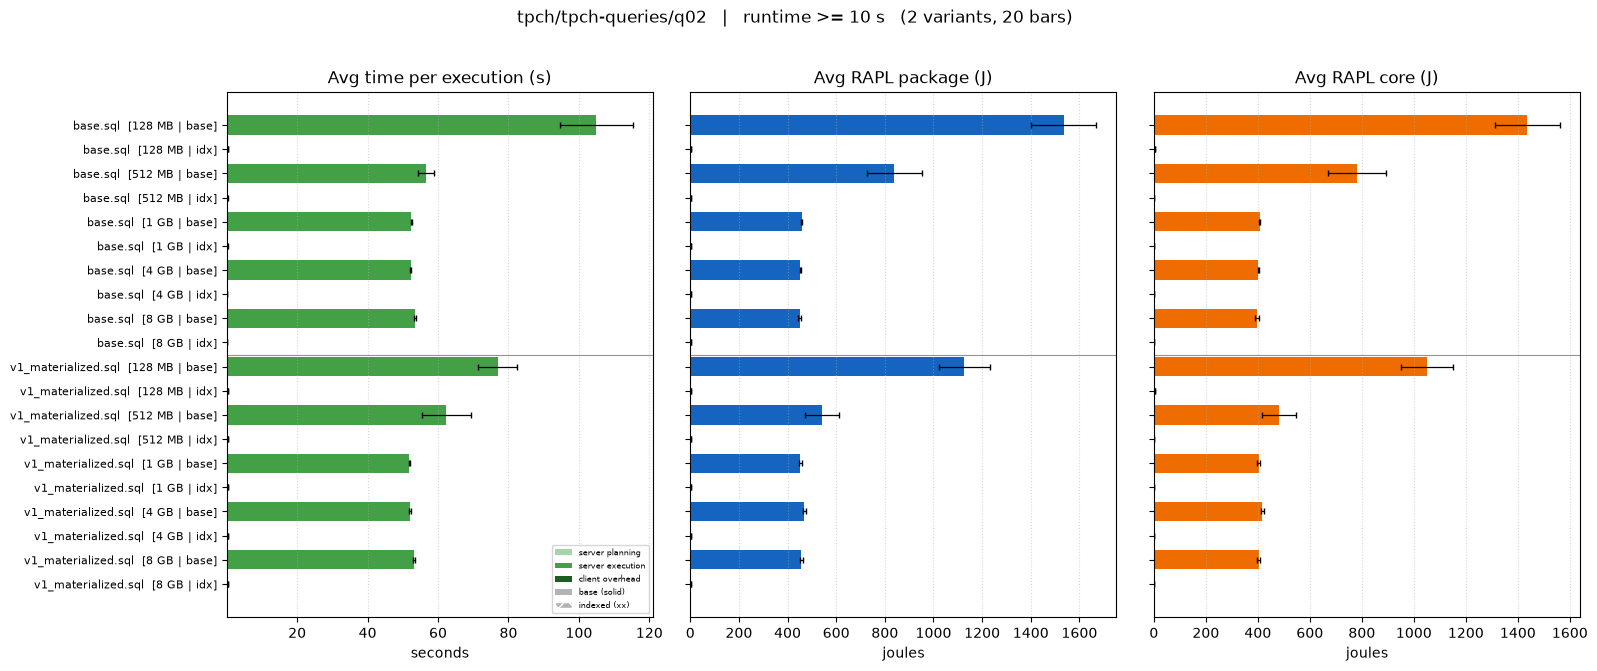

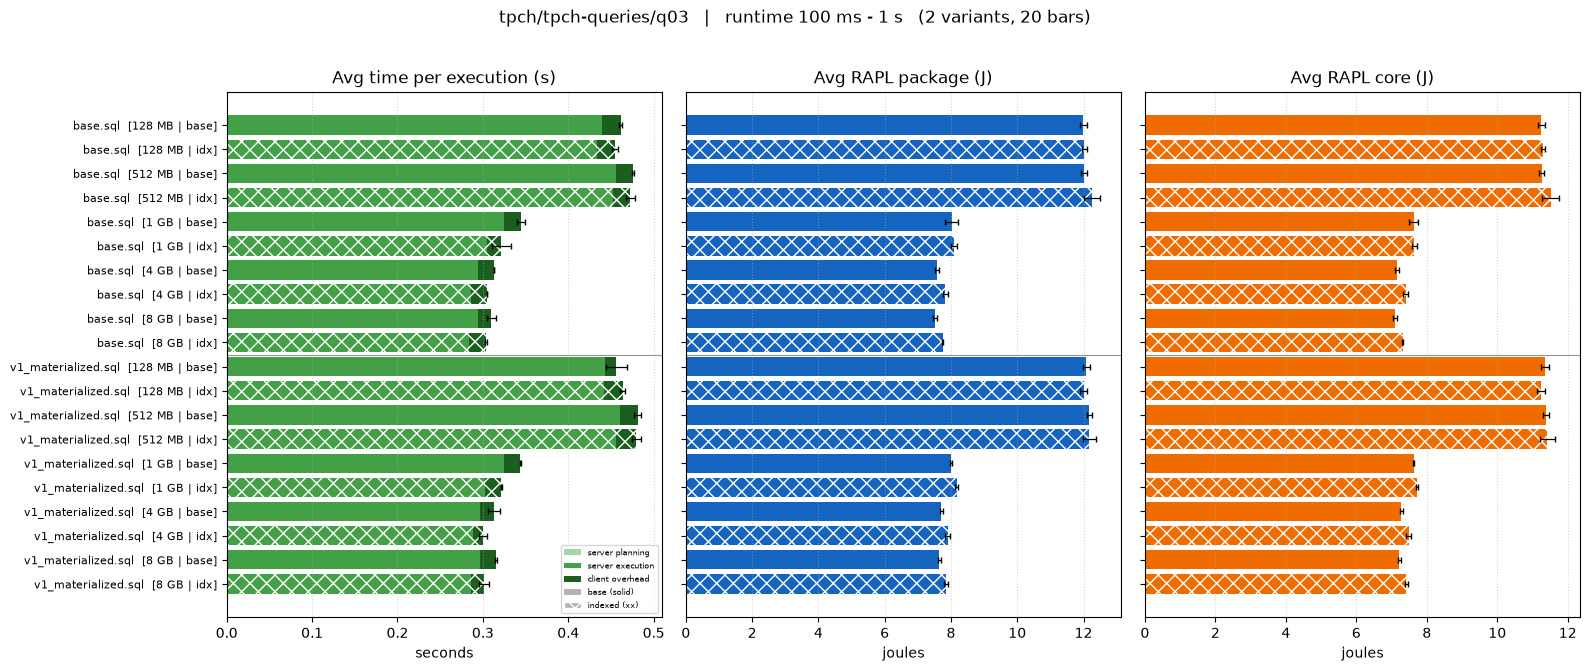

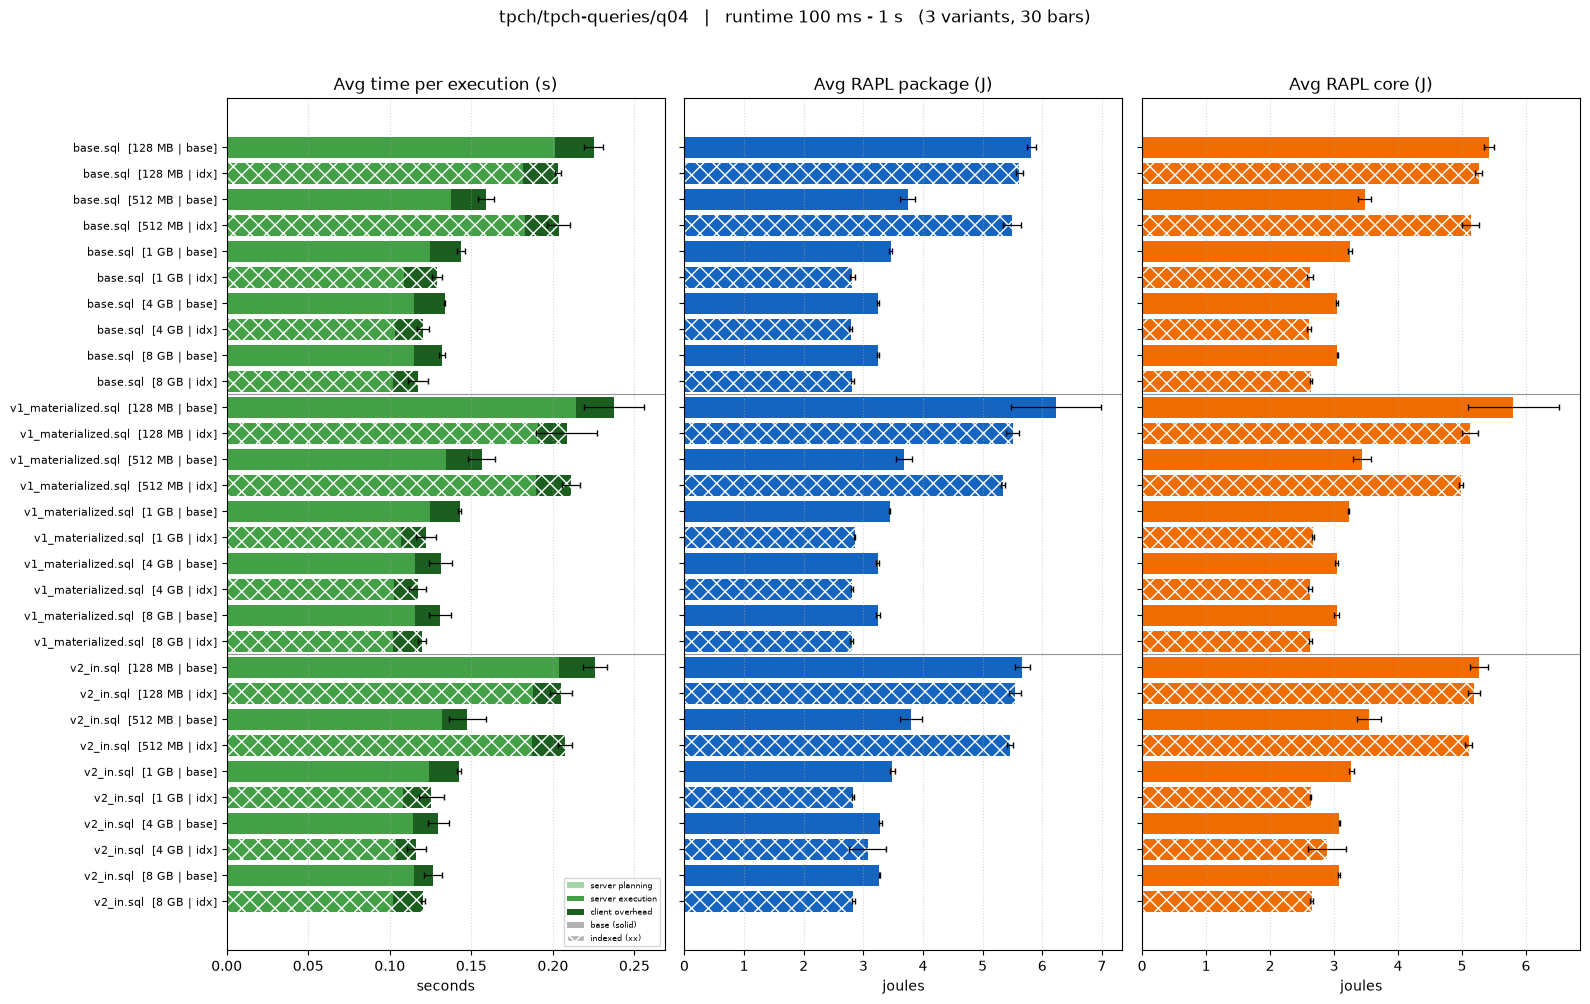

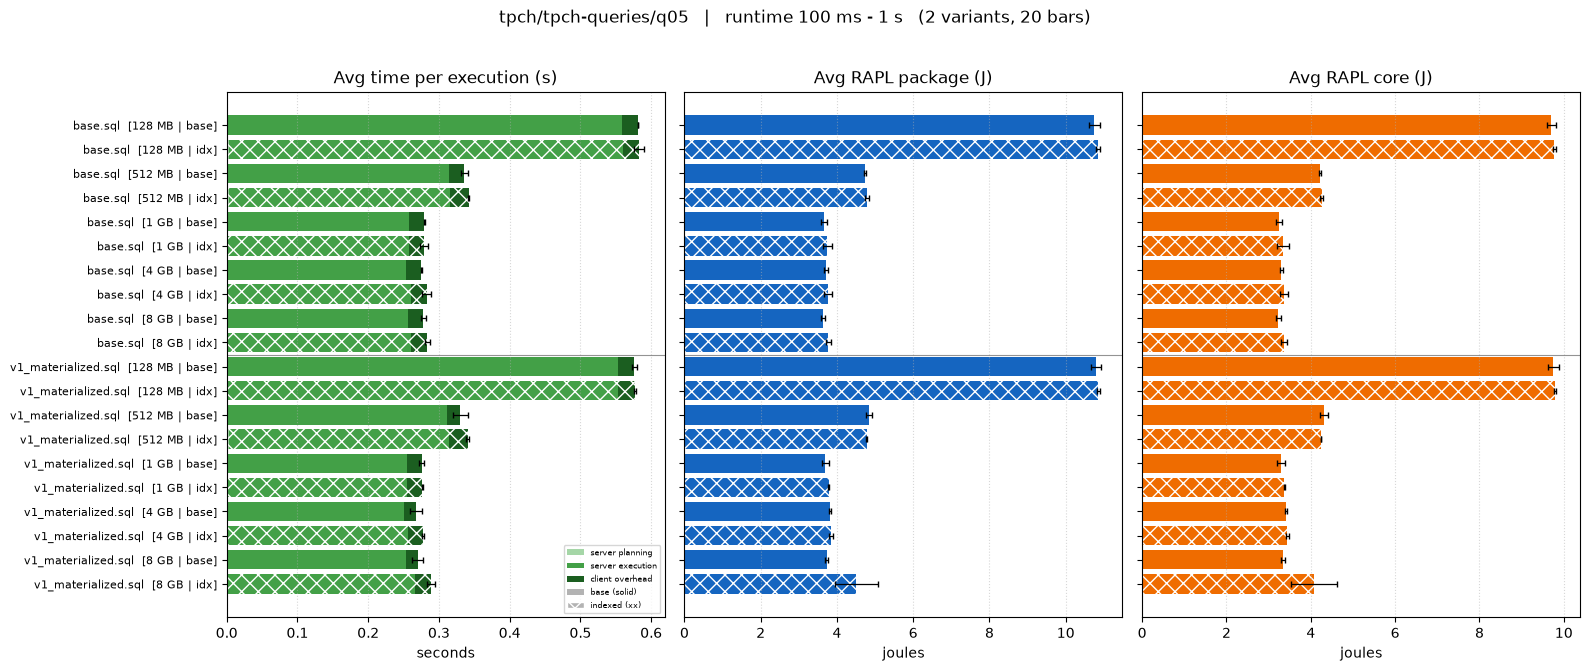

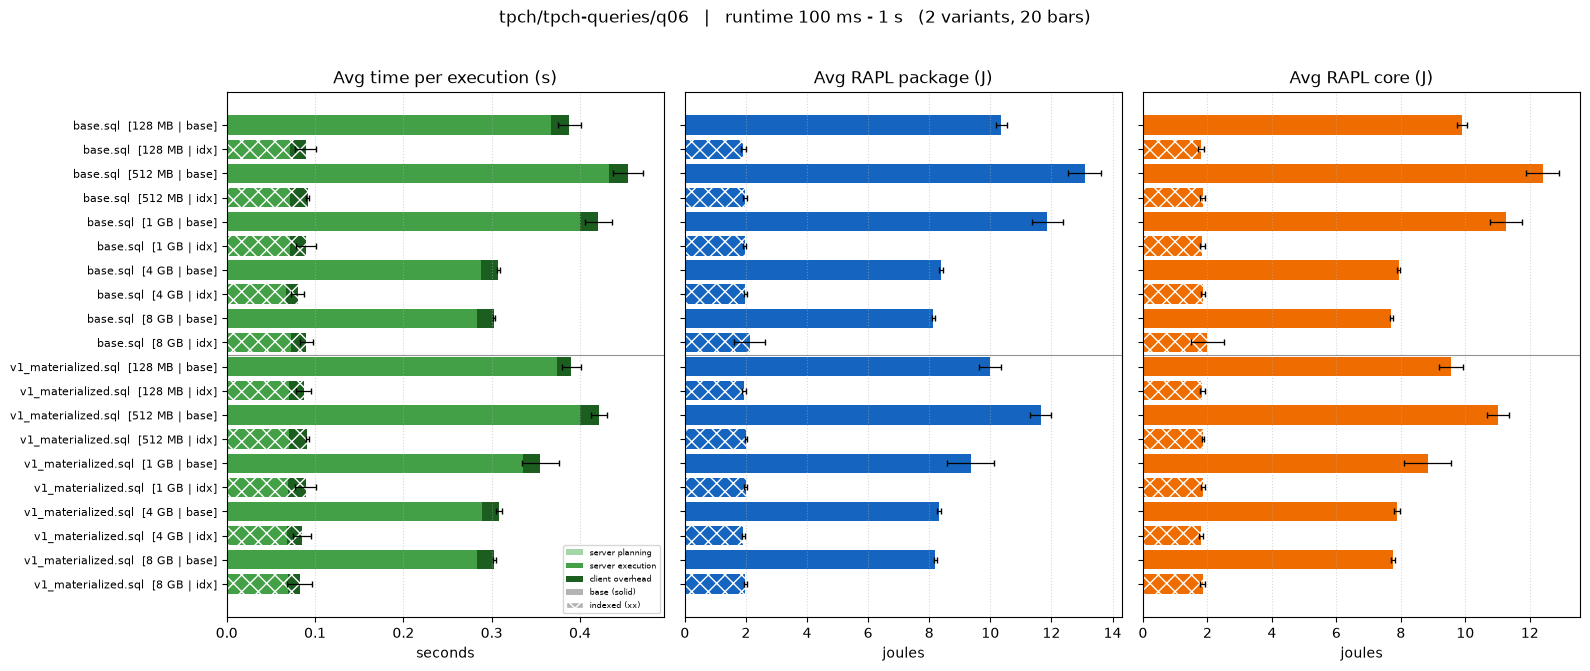

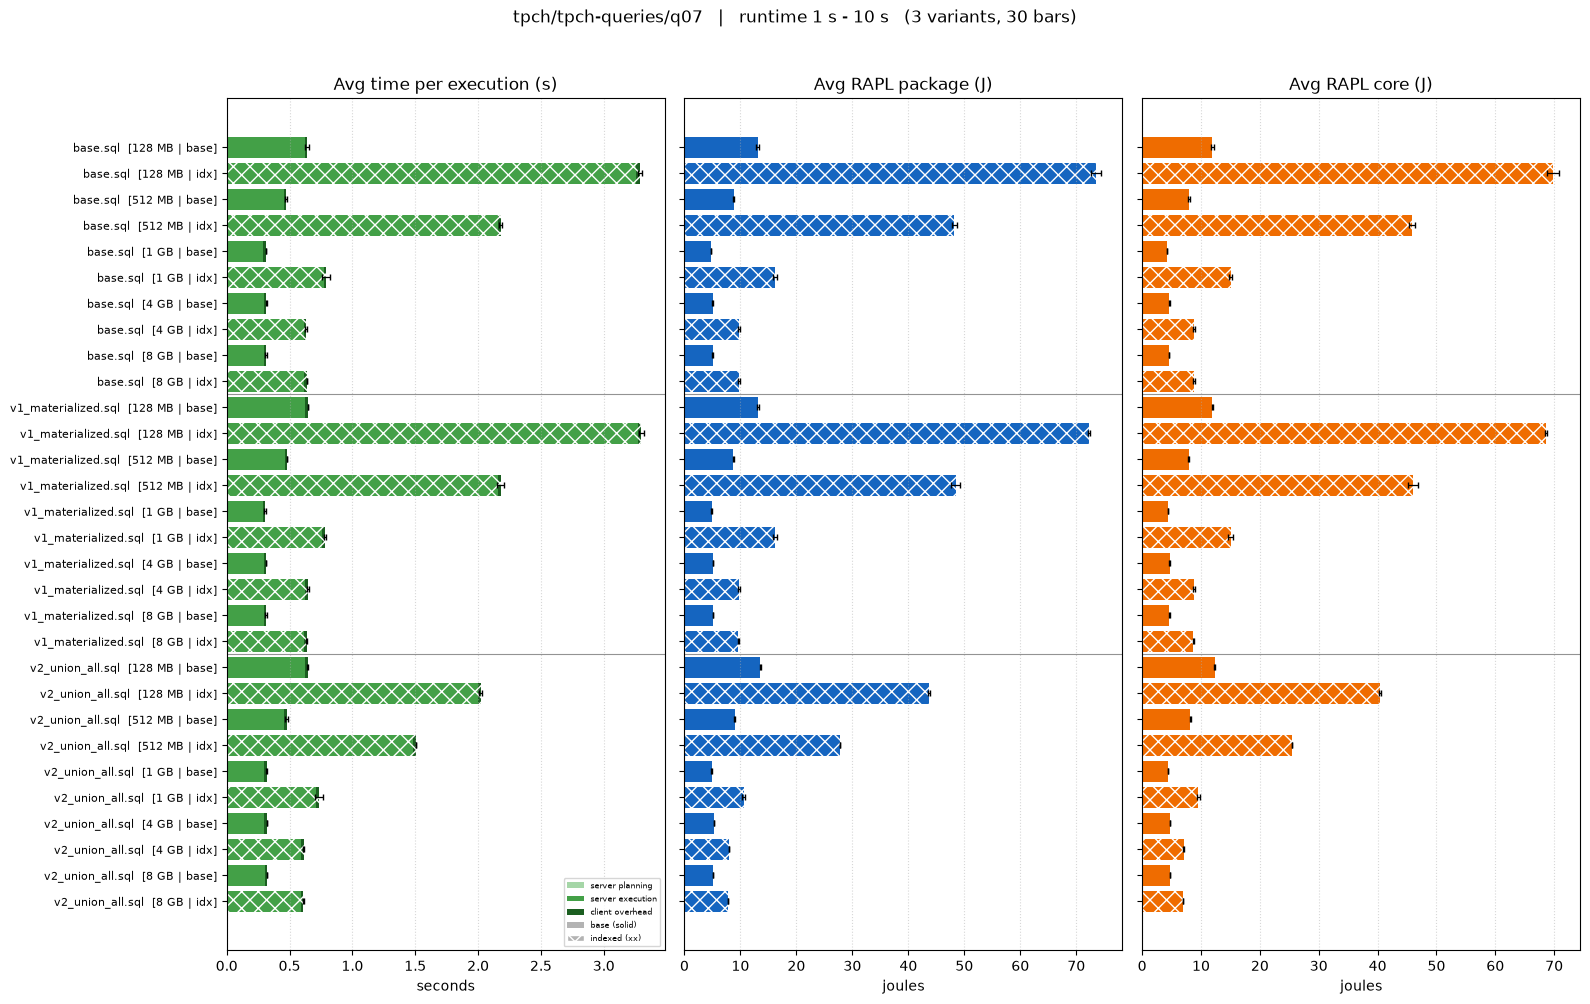

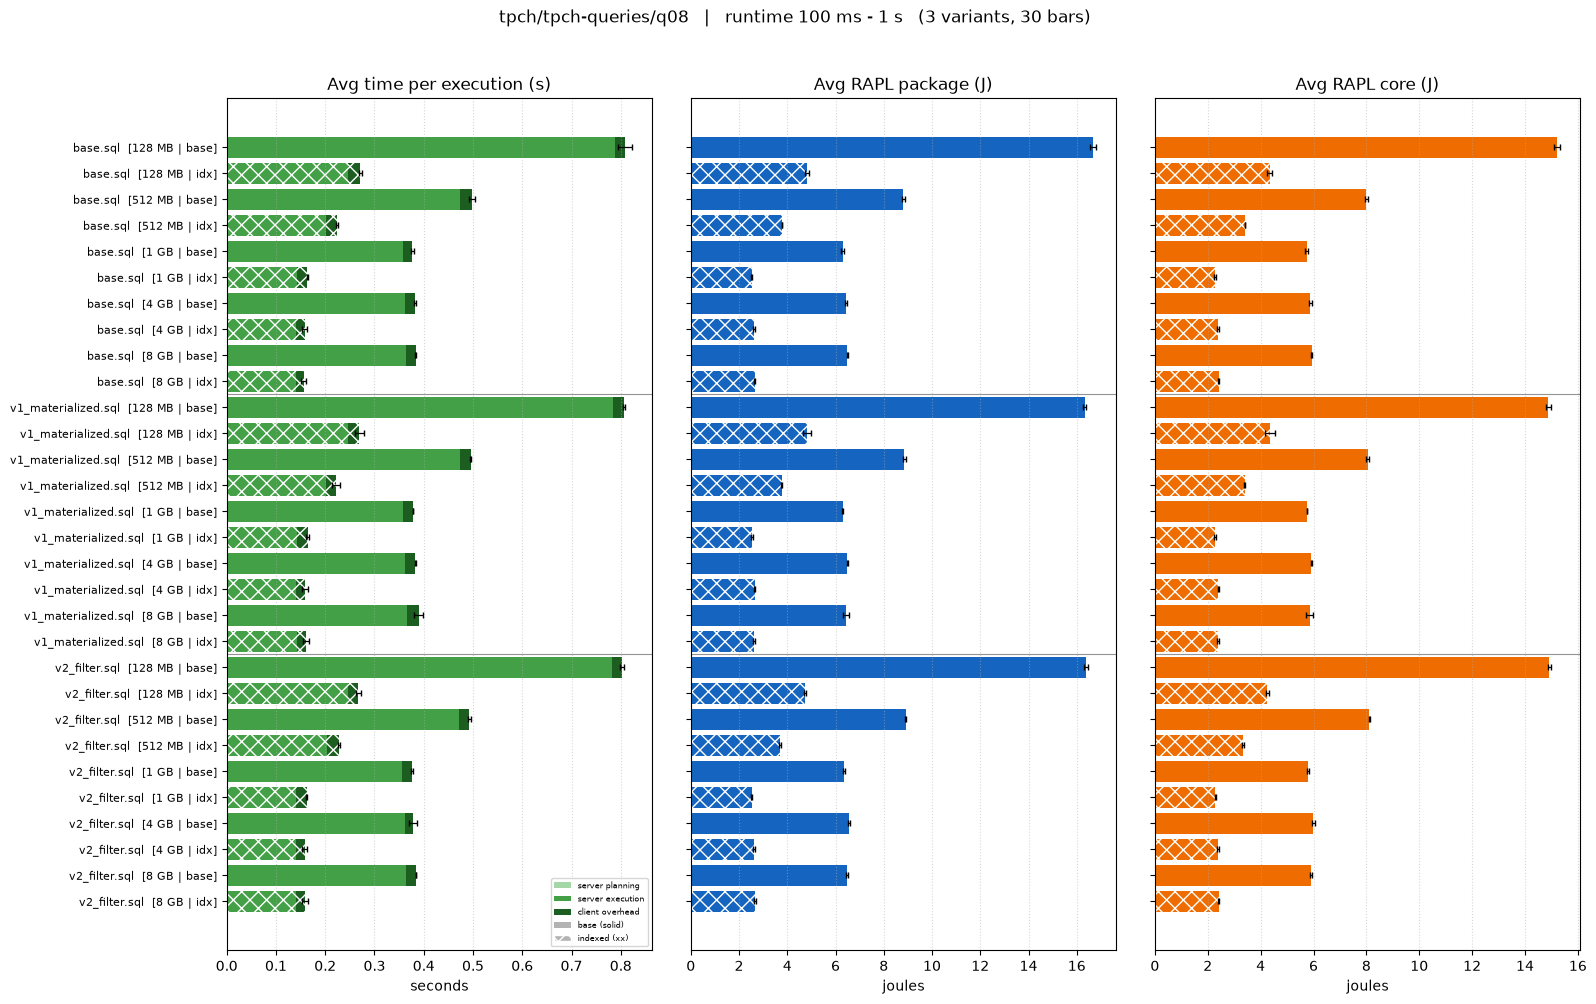

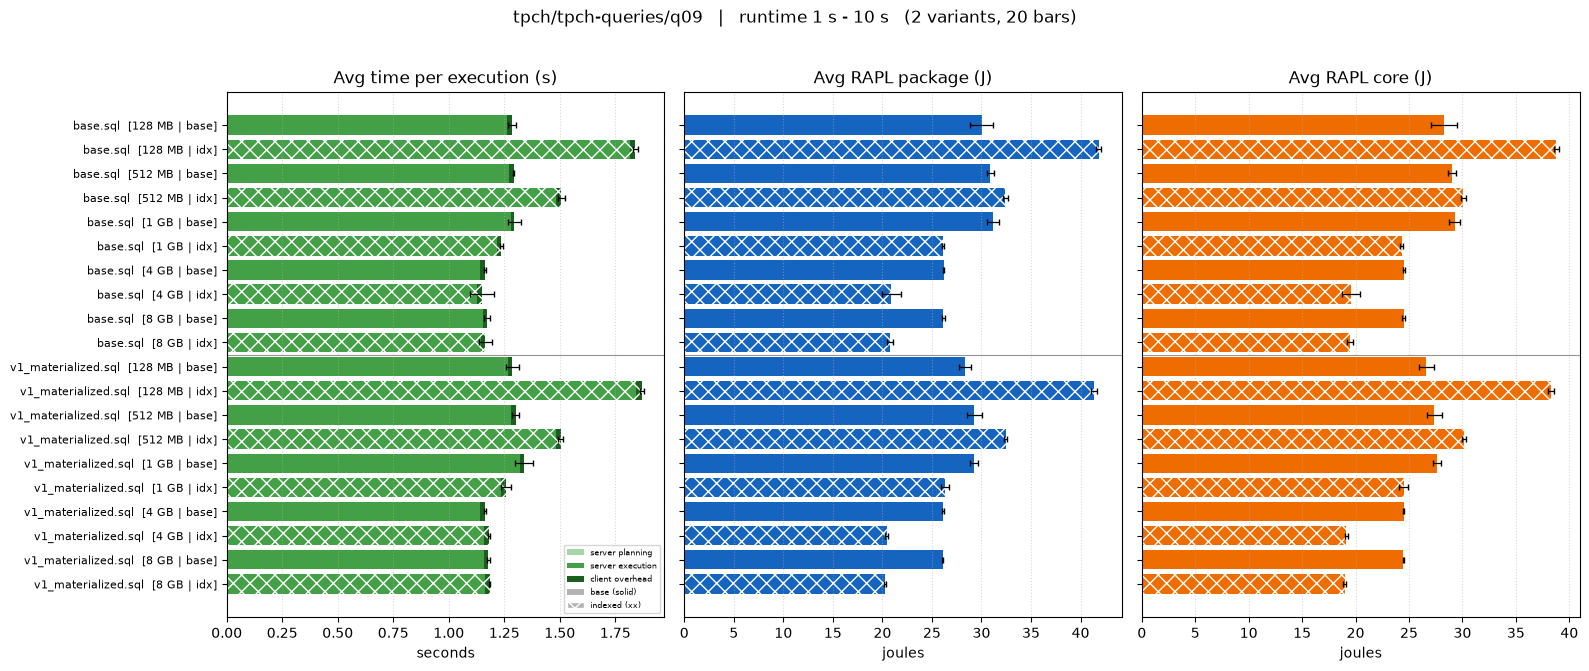

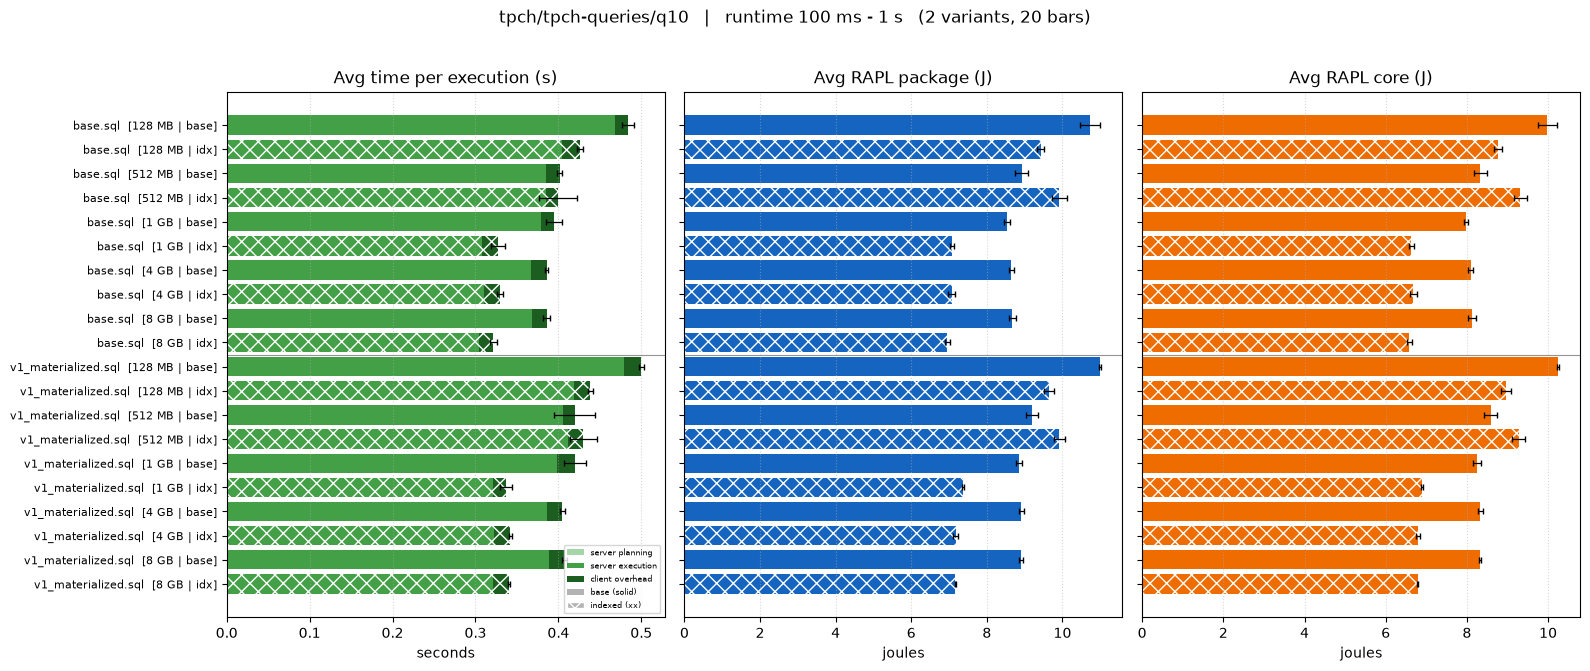

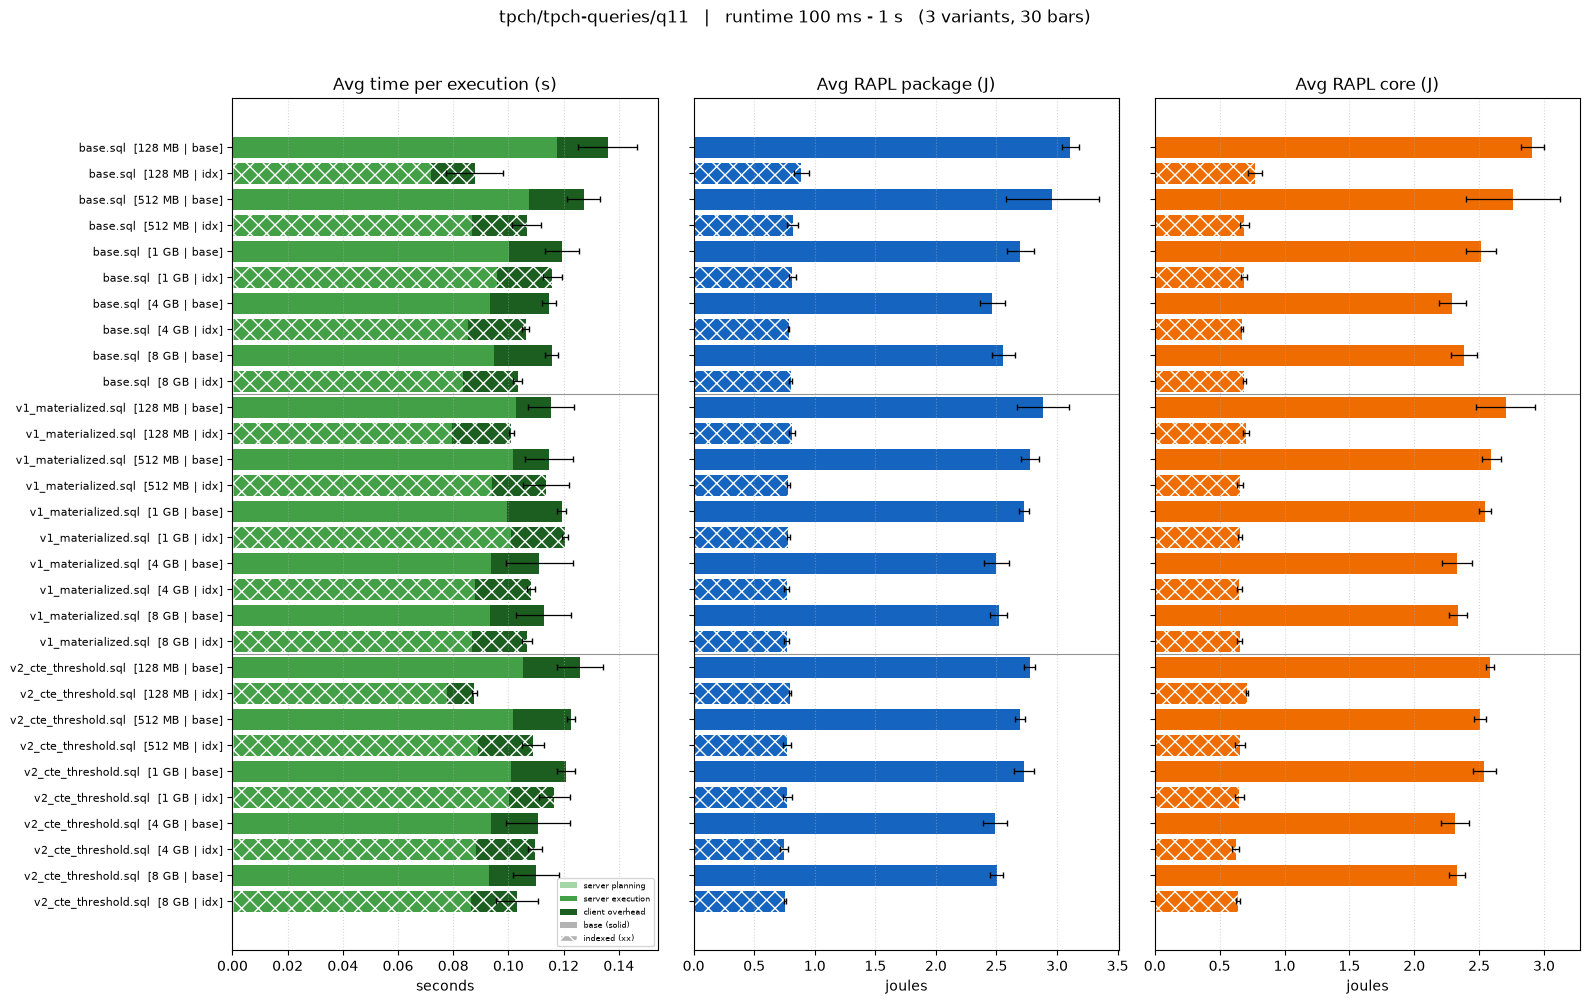

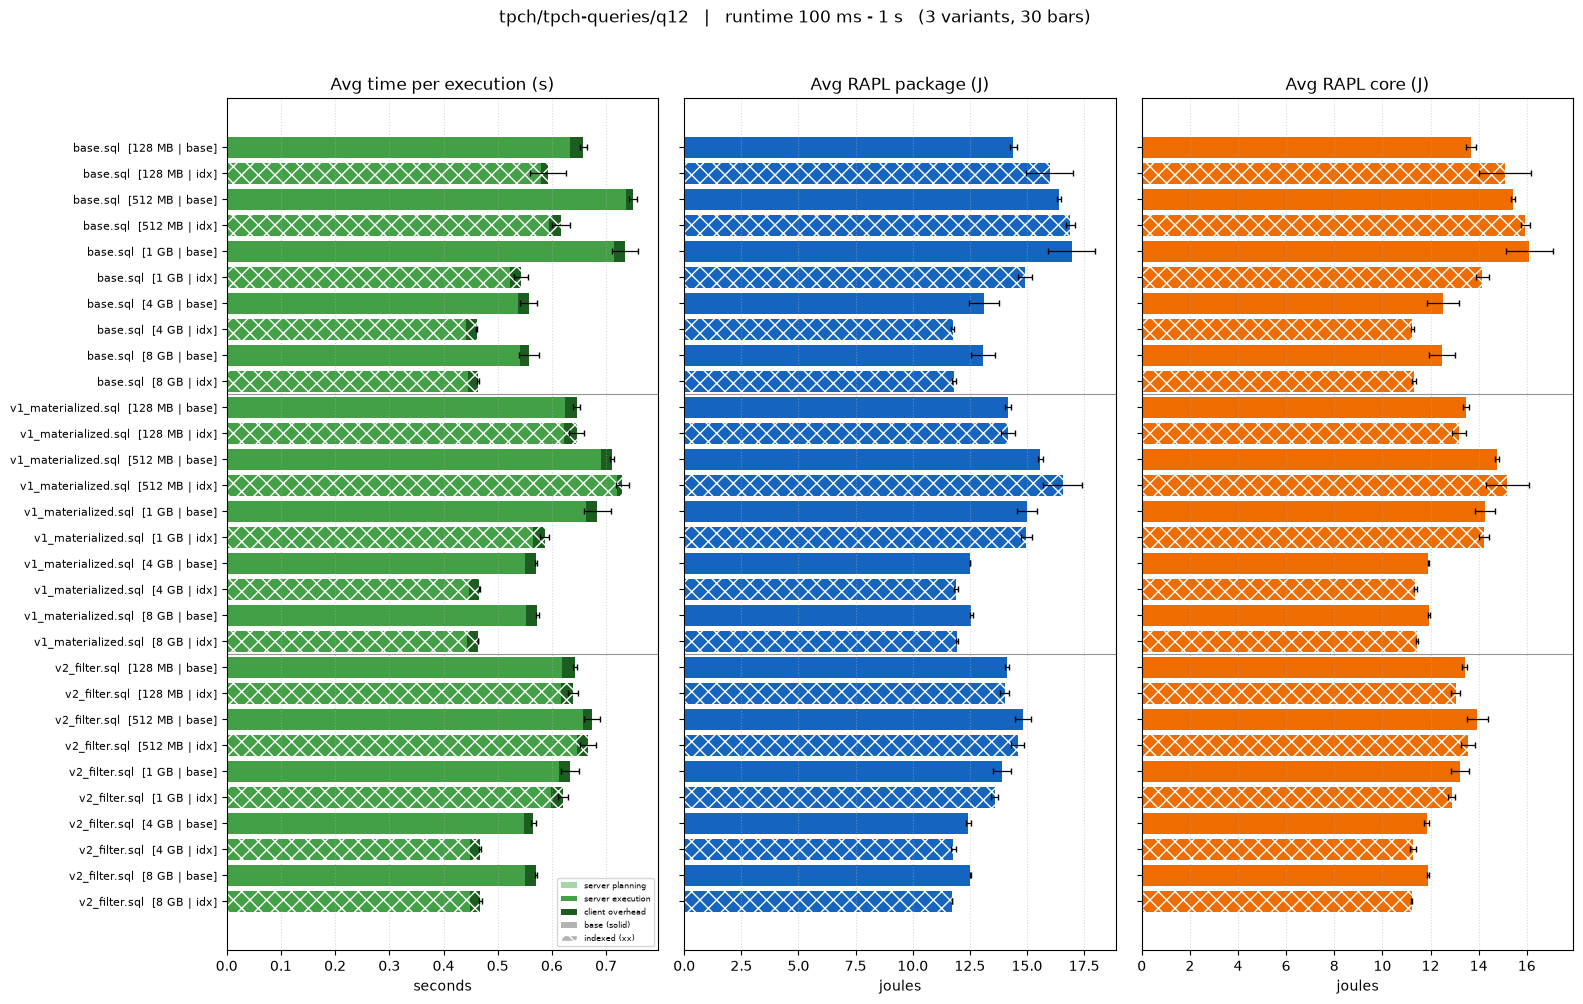

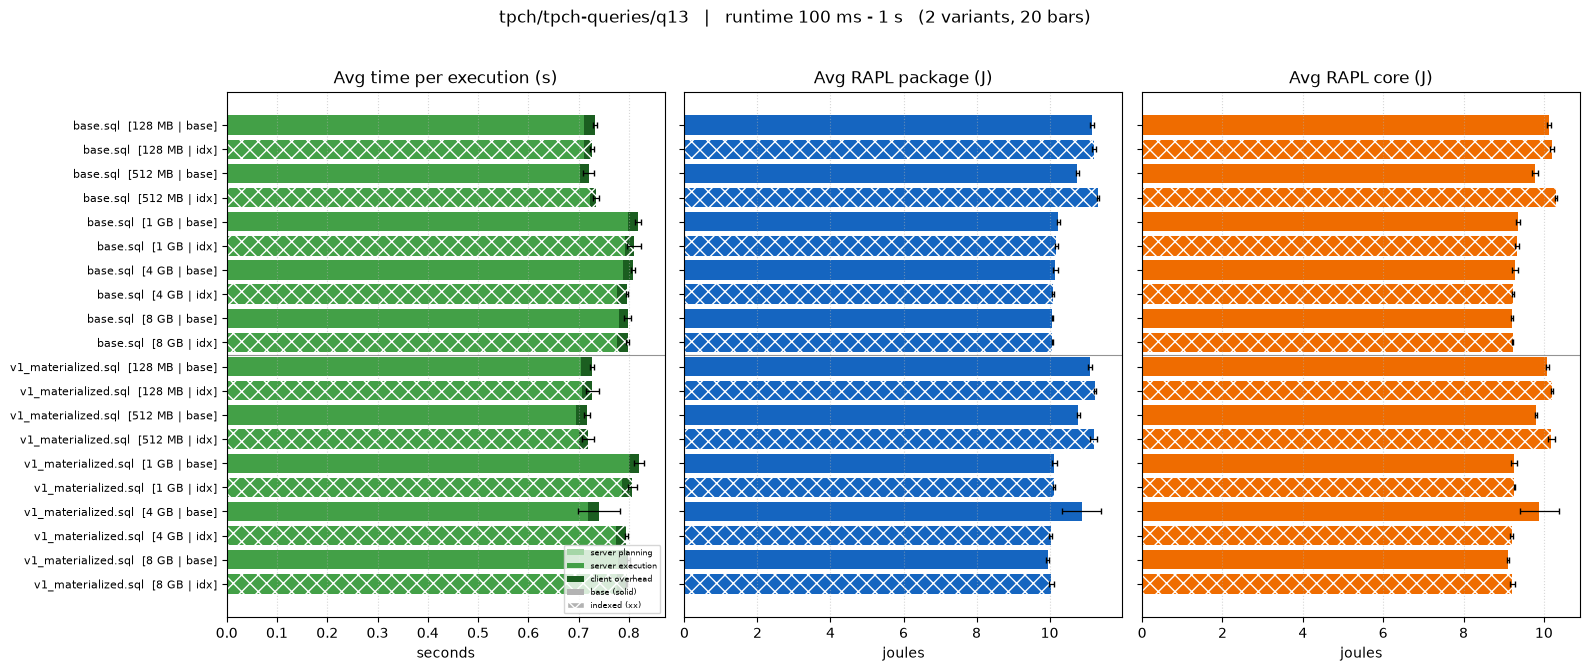

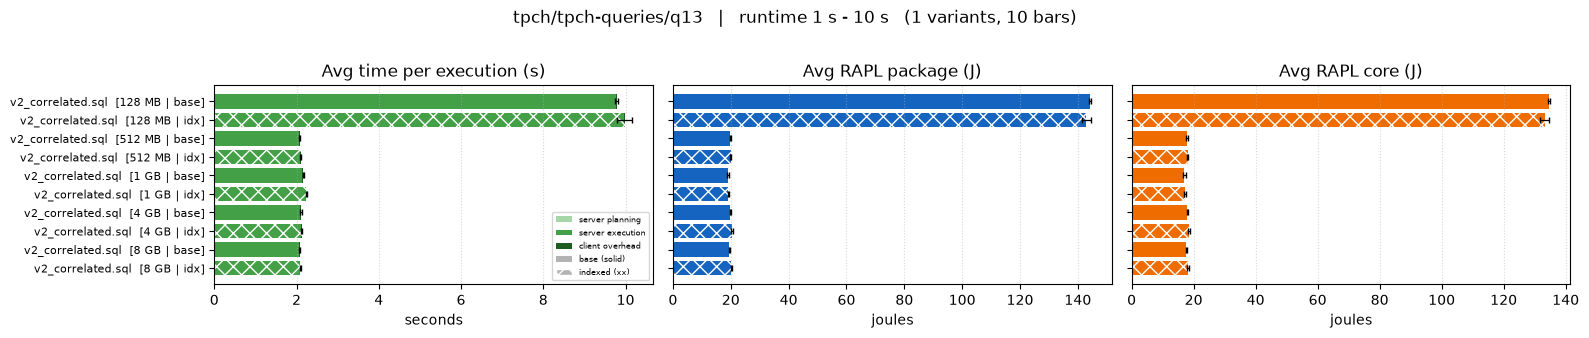

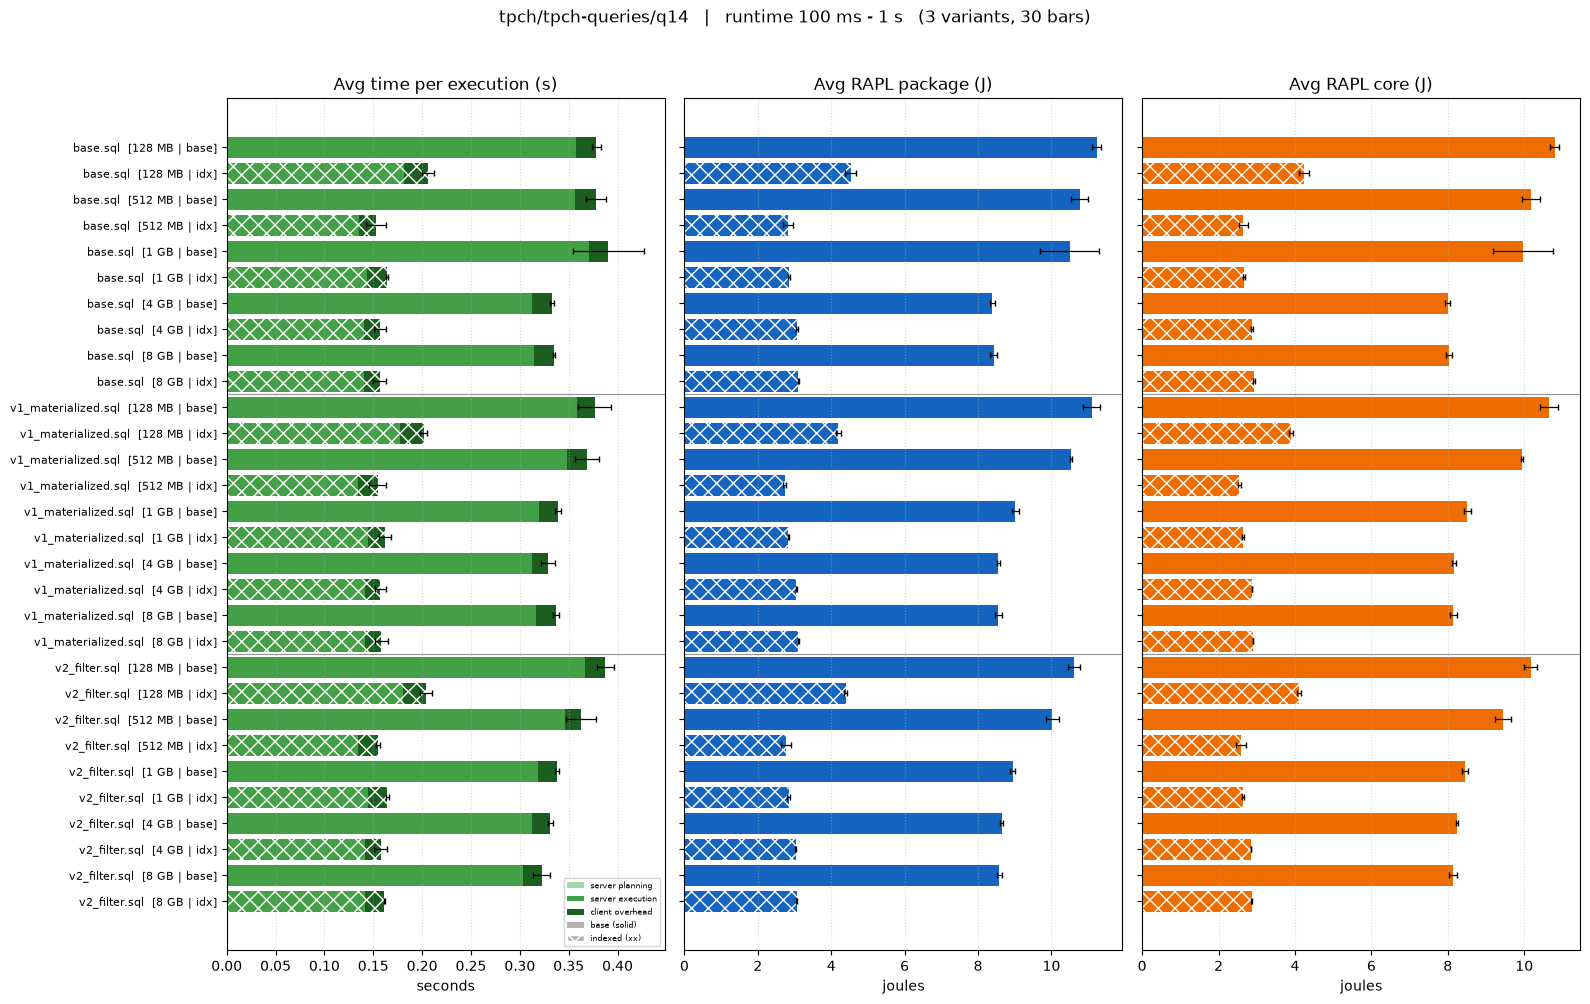

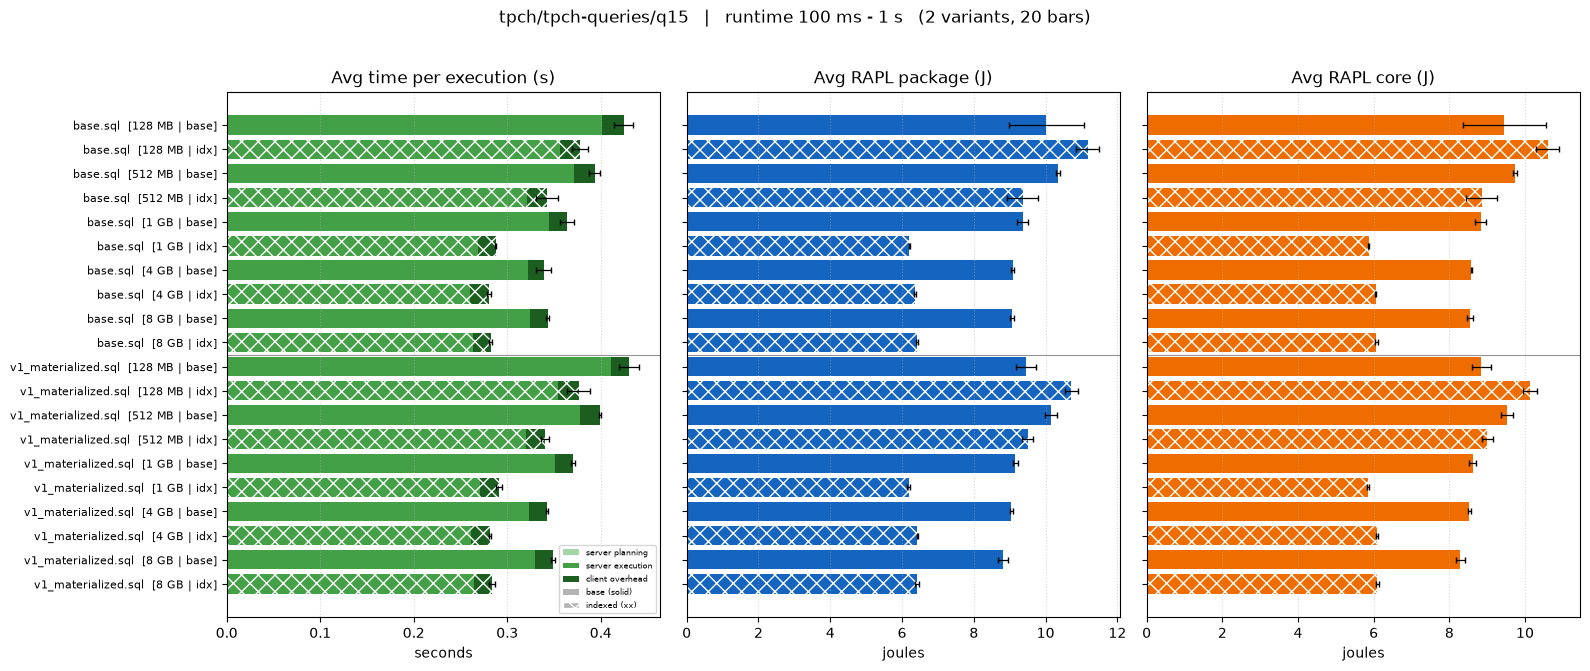

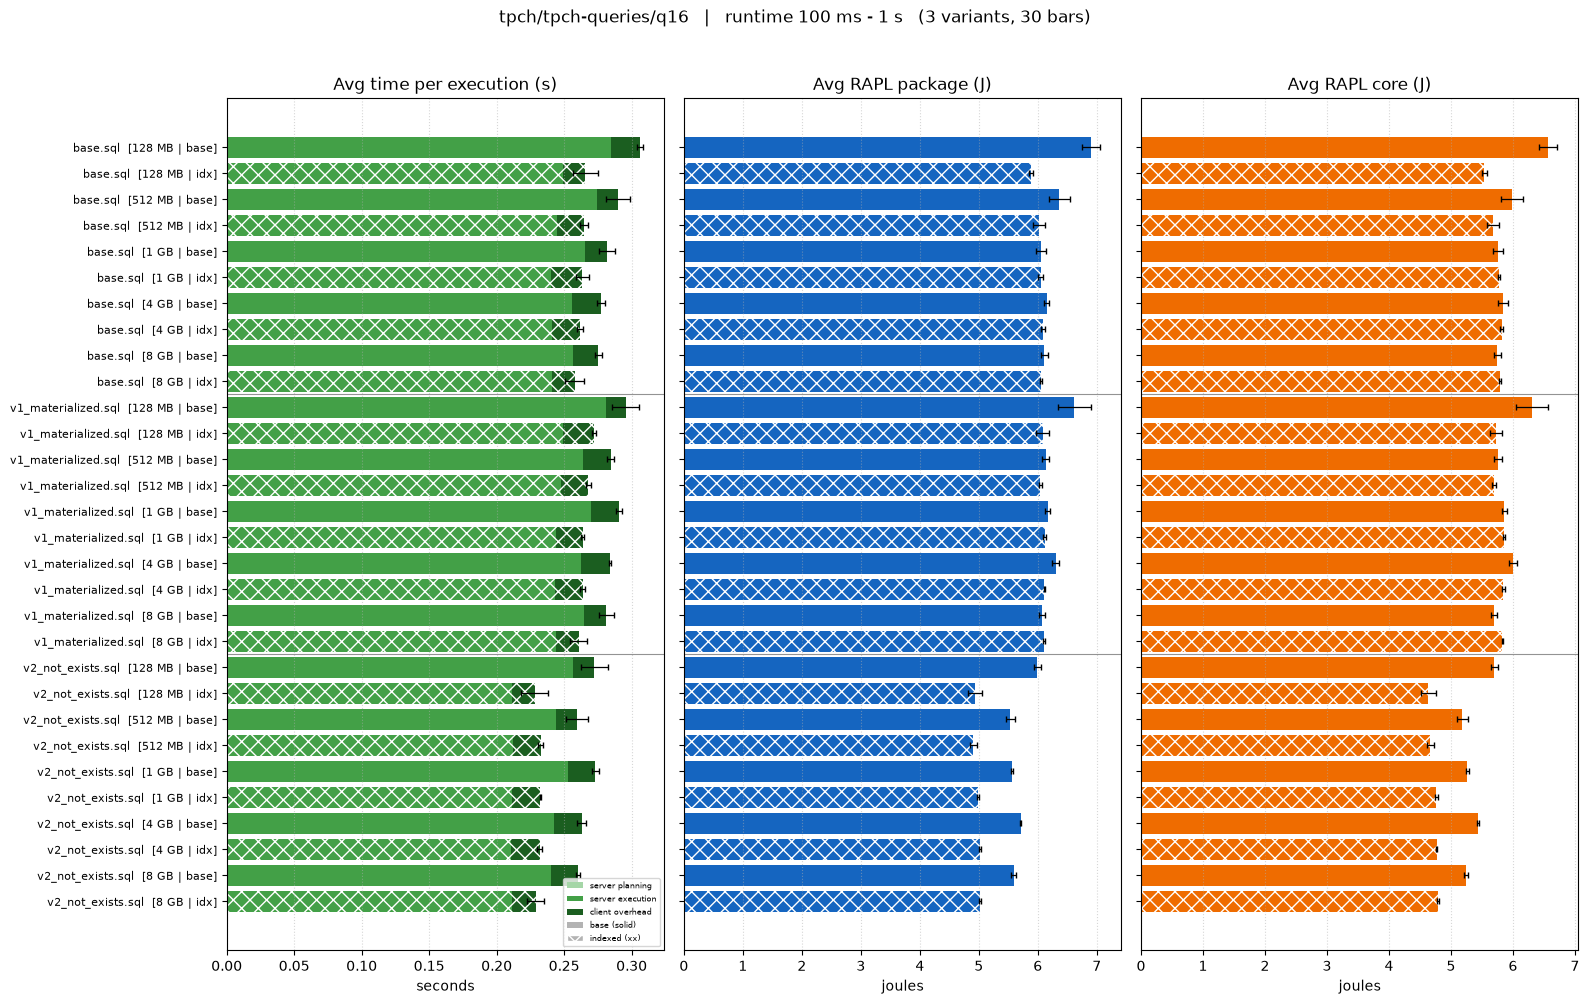

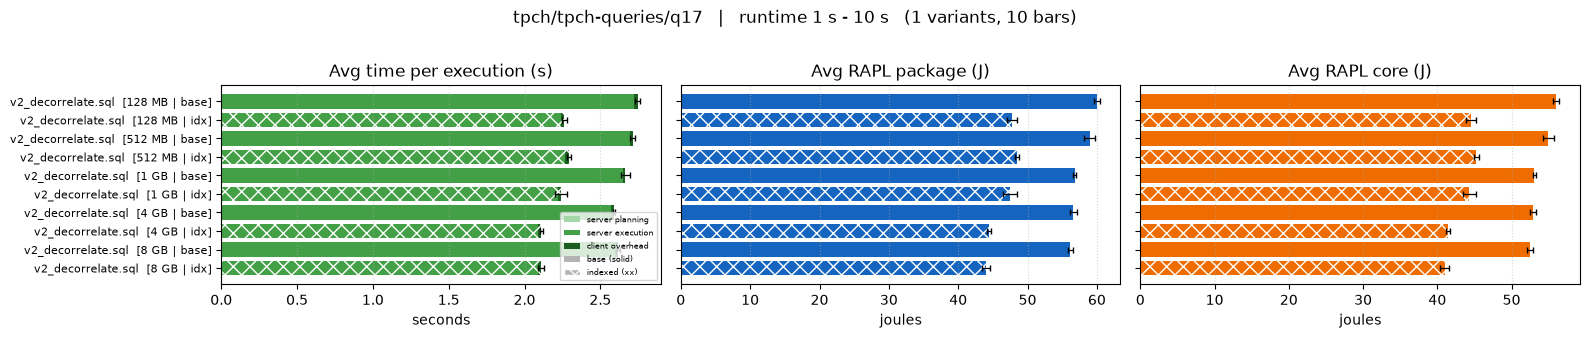

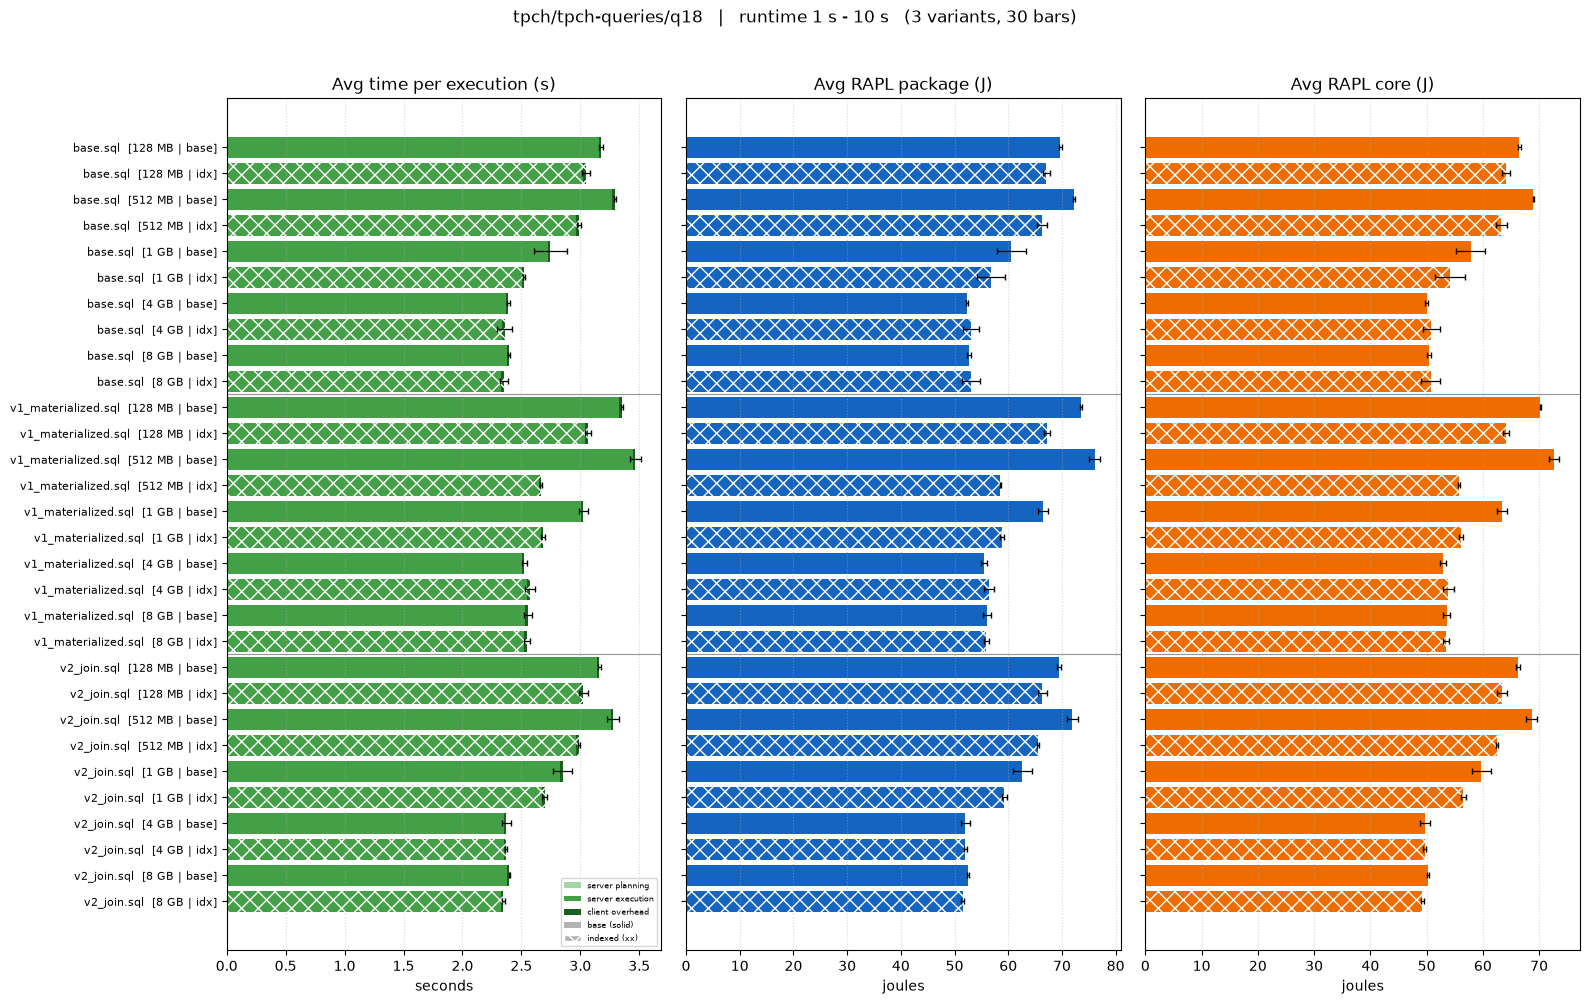

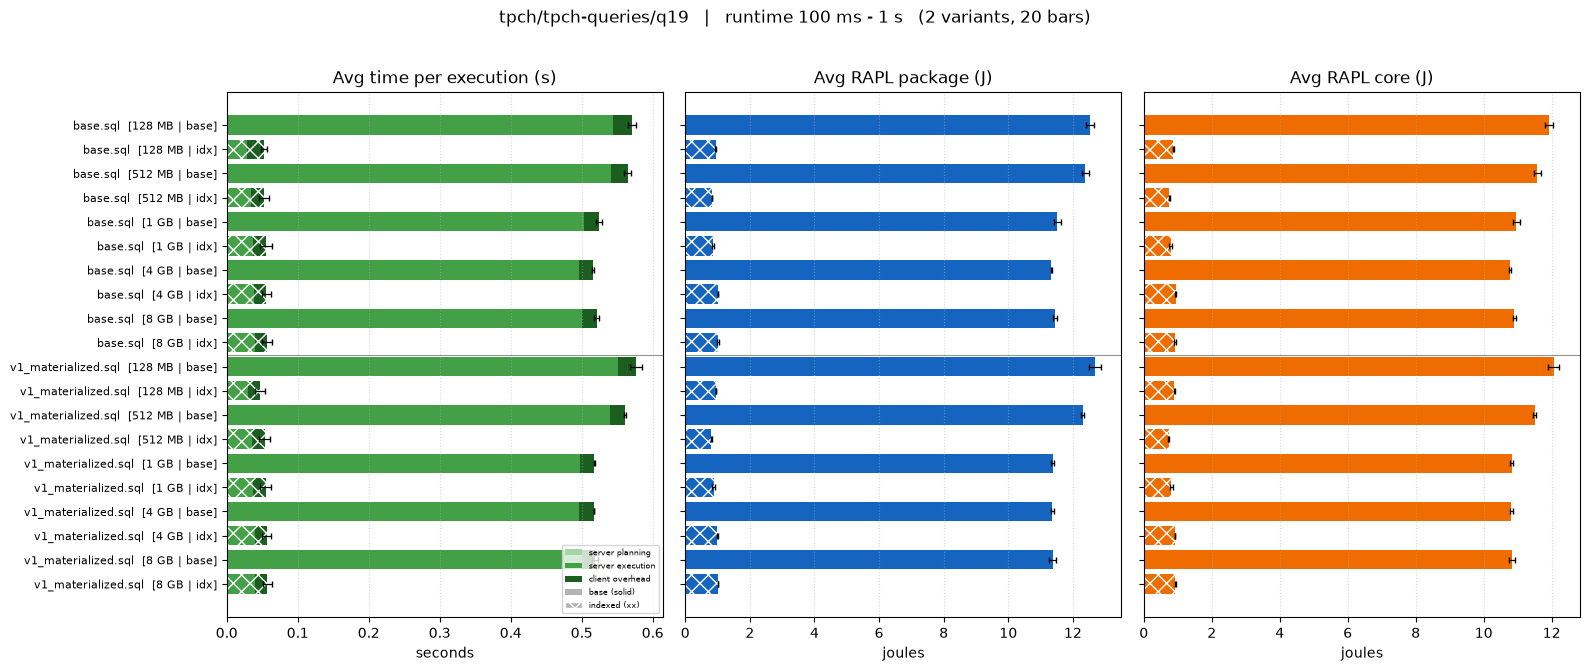

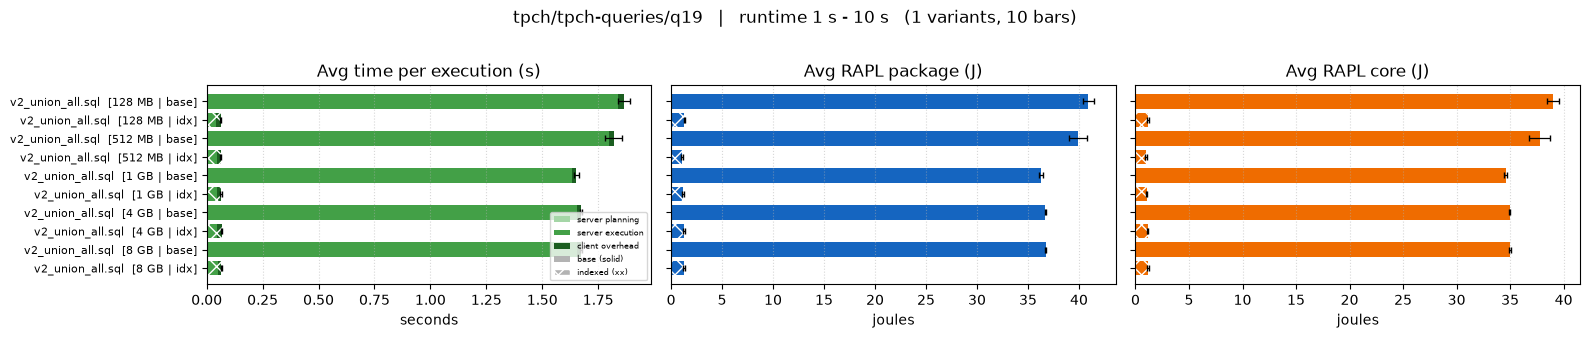

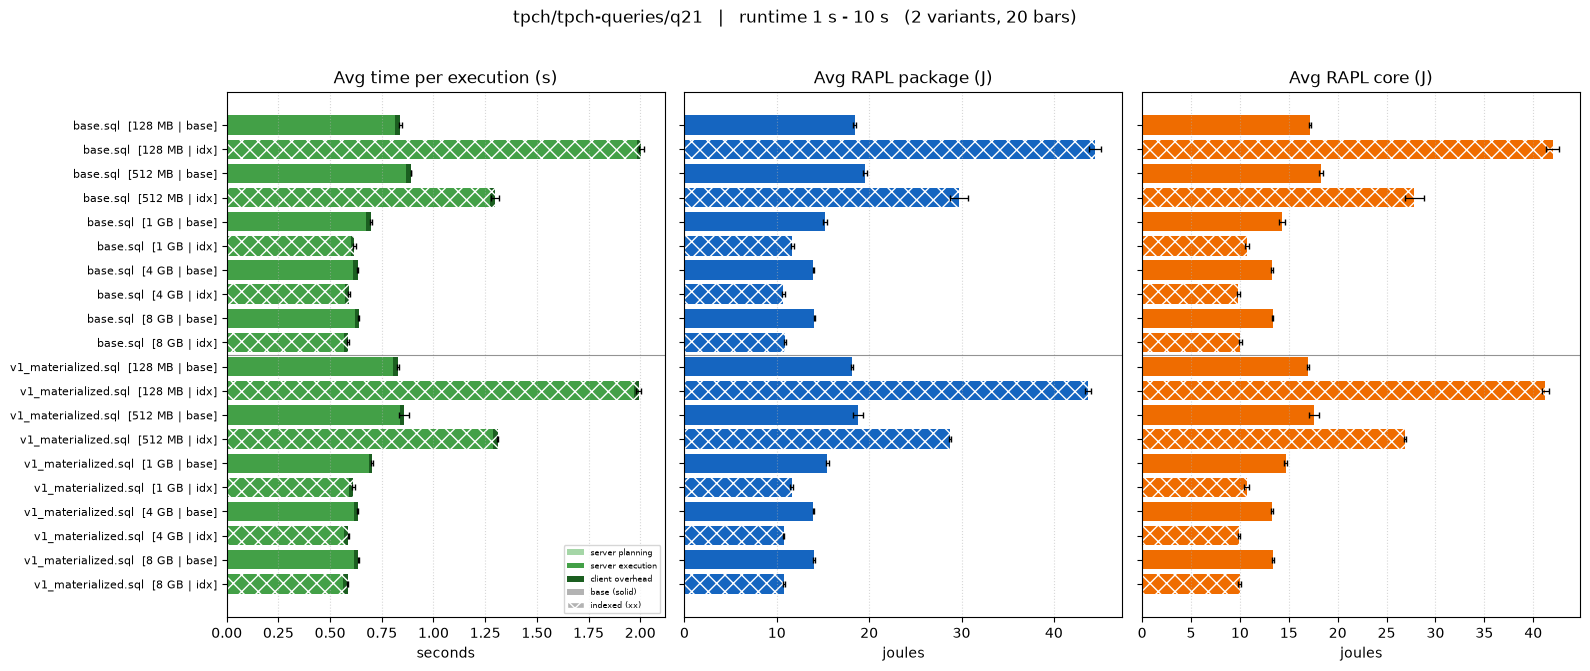

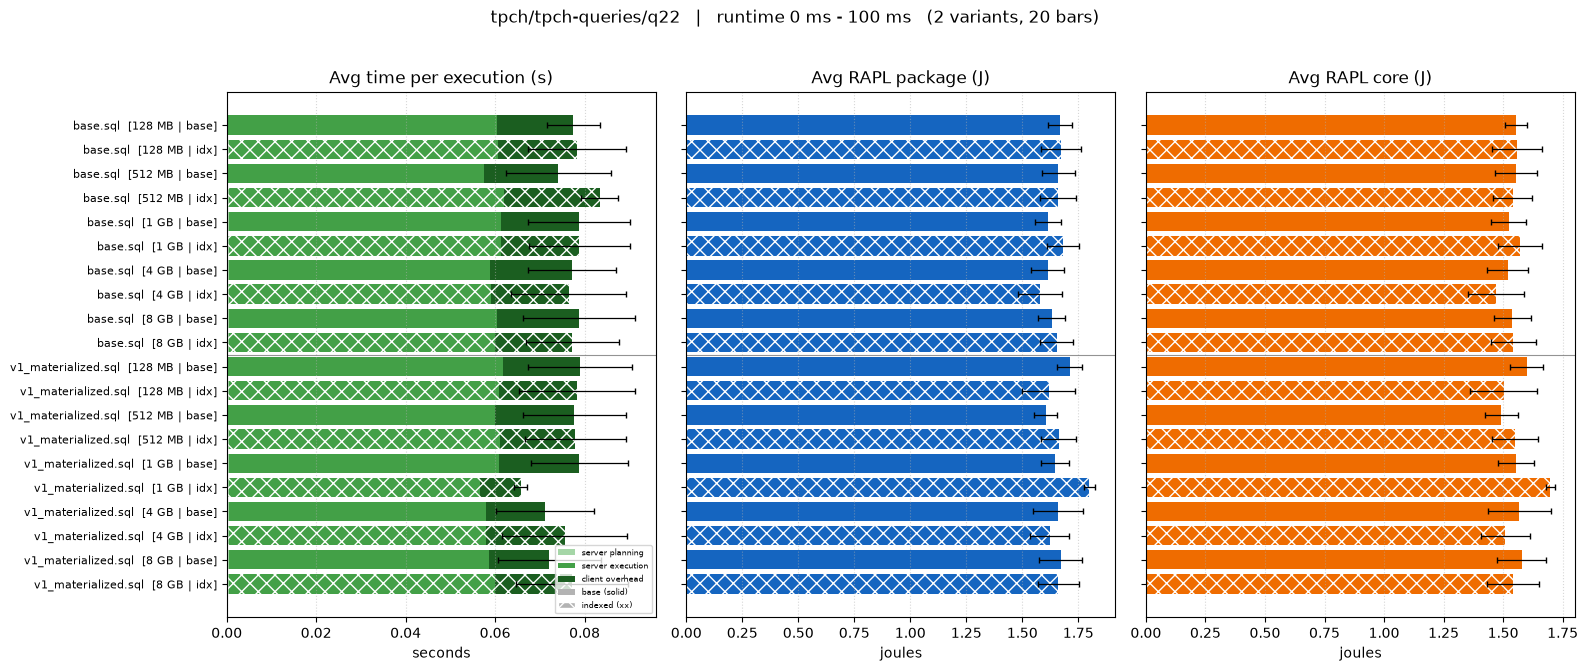

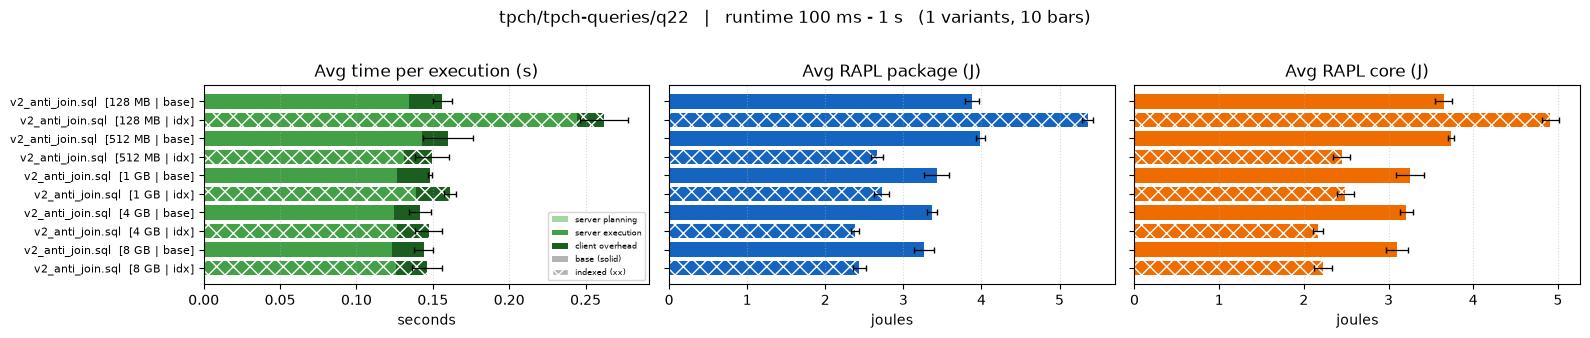

In [3]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

GROUPS = None                      # query folders to draw; None = all
RUNTIME_BINS = [0.0, 0.1, 1.0, 10.0]   # bin START values in seconds
BIN_STAT = "max"                   # "max" | "median" | "min" | "mean"
MAX_FIGURES = 250

COMPONENTS = [
    ("plan_s", "#a5d6a7", "server planning"),
    ("exec_s", "#43a047", "server execution"),
    ("overhead_s", "#1b5e20", "client overhead"),
]
IDX_HATCH = "xx"
edges = list(RUNTIME_BINS) + [np.inf]


def fmt_t(s):
    return f"{s * 1000:g} ms" if s < 1 else f"{s:g} s"


def bin_name(i):
    lo, hi = edges[i], edges[i + 1]
    return f">= {fmt_t(lo)}" if np.isinf(hi) else f"{fmt_t(lo)} - {fmt_t(hi)}"


all_groups = sorted(data["group"].dropna().unique())
groups = all_groups if GROUPS is None else [g for g in all_groups if g in GROUPS]

qrep = data.groupby("query")["avg_time_s"].agg(BIN_STAT)
qbin = pd.Series(np.digitize(qrep.to_numpy(), edges[1:], right=False),
                 index=qrep.index)
qbin[qrep.isna()] = -1
dq = data.copy()
dq["_bin"] = dq["query"].map(qbin)
dq["_idx_ord"] = (dq["index_status"] == "idx").astype(int)
dq["plab"] = (dq["sql_file"] + "  [" + dq["sb_label"]
              + " | " + dq["index_status"] + "]")

tasks = []
for group in groups:
    gb = dq.loc[dq["group"] == group, "_bin"]
    for i in sorted(b for b in gb.dropna().unique() if b >= 0):
        tasks.append((group, int(i)))
print(f"{len(groups)} query folder(s) -> {len(tasks)} figures")
if len(tasks) > MAX_FIGURES:
    print(f"capping to {MAX_FIGURES}")
    tasks = tasks[:MAX_FIGURES]


def hatch_idx(container, is_idx):
    for bar, ix in zip(container, is_idx):
        if ix:
            bar.set_hatch(IDX_HATCH)
            bar.set_edgecolor("white")
            bar.set_linewidth(0.0)


for group, i in tasks:
    g = dq[(dq["group"] == group) & (dq["_bin"] == i)].copy()
    g = g.sort_values(["sql_file", "sb_mb", "_idx_ord"])
    y = np.arange(len(g))
    is_idx = (g["index_status"] == "idx").to_numpy()
    height = max(1.8, len(g) * 0.34)
    fig, axes = plt.subplots(1, 3, figsize=(16, height), sharey=True)

    ax = axes[0]
    left = np.zeros(len(g))
    for col, colour, _ in COMPONENTS:
        hatch_idx(ax.barh(y, g[col].fillna(0).to_numpy(dtype=float),
                          left=left, color=colour), is_idx)
        left += g[col].fillna(0).to_numpy(dtype=float)
    std = g["time_std"].to_numpy(dtype=float)
    ok = ~np.isnan(std)
    if ok.any():
        ax.errorbar(left[ok], y[ok], xerr=std[ok], fmt="none",
                    ecolor="black", elinewidth=0.9, capsize=2)
    ax.set_title("Avg time per execution (s)"); ax.set_xlabel("seconds")
    handles = [Patch(facecolor=c, label=l) for _, c, l in COMPONENTS]
    handles += [Patch(facecolor="0.7", label="base (solid)"),
                Patch(facecolor="0.7", hatch=IDX_HATCH, edgecolor="white",
                      label="indexed (xx)")]
    ax.legend(handles=handles, fontsize=6, loc="lower right")

    for ax, col, scol, colour, title in (
        (axes[1], "avg_pkg_j", "pkg_j_std", "#1565c0", "Avg RAPL package (J)"),
        (axes[2], "avg_core_j", "core_j_std", "#ef6c00", "Avg RAPL core (J)"),
    ):
        vals = g[col].to_numpy(dtype=float)
        hatch_idx(ax.barh(y, np.nan_to_num(vals), color=colour), is_idx)
        estd = g[scol].to_numpy(dtype=float)
        eok = ~np.isnan(estd) & ~np.isnan(vals)
        if eok.any():
            ax.errorbar(vals[eok], y[eok], xerr=estd[eok], fmt="none",
                        ecolor="black", elinewidth=0.9, capsize=2)
        ax.set_title(title); ax.set_xlabel("joules")

    sql = g["sql_file"].to_numpy()
    bounds = [k - 0.5 for k in range(1, len(g)) if sql[k] != sql[k - 1]]
    for ax in axes:
        ax.grid(axis="x", linestyle=":", alpha=0.5)
        for yb in bounds:
            ax.axhline(yb, color="0.4", lw=0.8, alpha=0.7)
    axes[0].set_yticks(y); axes[0].set_yticklabels(g["plab"], fontsize=8)
    axes[0].invert_yaxis()
    fig.suptitle(f"{group}   |   runtime {bin_name(i)}   "
                 f"({g['sql_file'].nunique()} variants, {len(g)} bars)", fontsize=12)
    fig.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()

## 4. Buffer cache hit rate & disk reads vs shared_buffers

The whole point of `shared_buffers`: bigger buffer cache ⇒ more pages served
from memory (`shared_hit`) and fewer read from the OS/disk (`shared_read`). For
each query we have the hit rate and the read volume at every size; below is the
**median across queries** (with the inter-quartile band) for base and indexed,
plus the queries whose hit rate climbs the most as the cache grows.

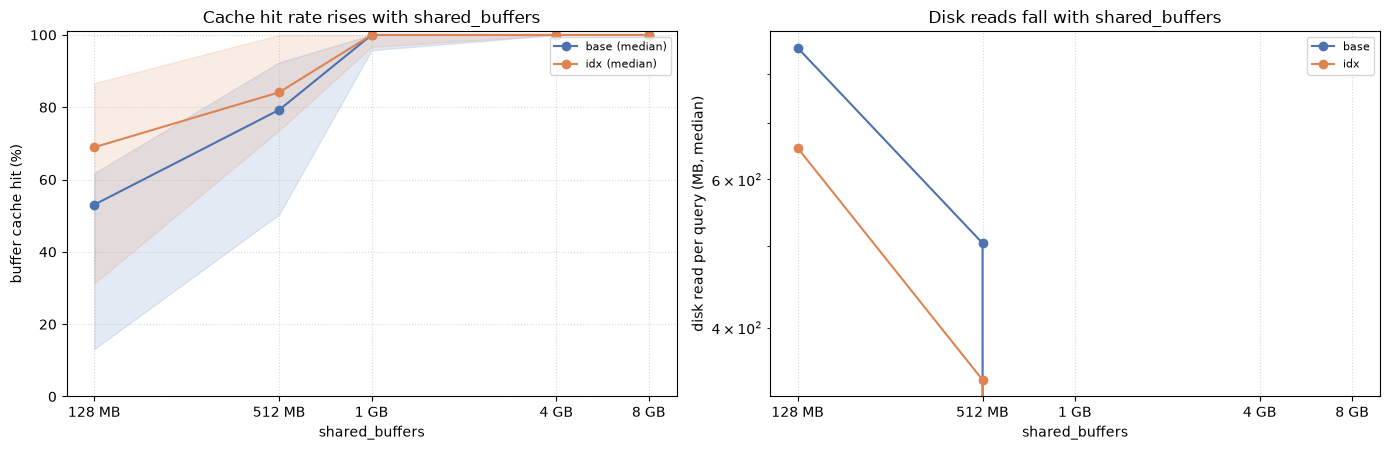

Queries whose cache hit % gains most from 128 MB -> 8 GB (base):
                         hit% @128 MB  hit% @8 GB  gain_pp
qid                                                       
q01/base.sql                      2.3       100.0     97.7
q12/base.sql                      3.7       100.0     96.3
q14/base.sql                      4.2       100.0     95.8
q06/base.sql                      4.3       100.0     95.7
q17/v2_decorrelate.sql            6.4       100.0     93.6
q01/v1_materialized.sql           6.5       100.0     93.5
q06/v1_materialized.sql           8.6       100.0     91.4
q09/base.sql                      9.7       100.0     90.3
q09/v1_materialized.sql           9.7       100.0     90.3
q14/v1_materialized.sql           9.8       100.0     90.2
q12/v1_materialized.sql          10.1       100.0     89.9
q02/base.sql                     11.3       100.0     88.7


In [4]:
xcol = "sb_mb"
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
colours = {"base": "#4c72b0", "idx": "#dd8452"}

for ix in IDX_ALL:
    sub = data[data["index_status"] == ix]
    grp = sub.groupby(xcol)
    med = grp["cache_hit_pct"].median()
    q1 = grp["cache_hit_pct"].quantile(0.25)
    q3 = grp["cache_hit_pct"].quantile(0.75)
    axes[0].plot(med.index, med.values, marker="o", color=colours[ix],
                 label=f"{ix} (median)")
    axes[0].fill_between(med.index, q1.values, q3.values, color=colours[ix], alpha=0.15)
    rmed = grp["read_mb"].median()
    axes[1].plot(rmed.index, rmed.values, marker="o", color=colours[ix], label=ix)

axes[0].set_ylabel("buffer cache hit (%)"); axes[0].set_ylim(0, 101)
axes[0].set_title("Cache hit rate rises with shared_buffers")
axes[1].set_ylabel("disk read per query (MB, median)")
axes[1].set_yscale("log"); axes[1].set_title("Disk reads fall with shared_buffers")
for ax in axes:
    ax.set_xscale("log", base=2)
    ax.set_xticks(SB_ALL); ax.set_xticklabels([sb_label(m) for m in SB_ALL])
    ax.set_xlabel("shared_buffers"); ax.grid(linestyle=":", alpha=0.5); ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

base = data[data["index_status"] == "base"]
hp = base.pivot_table(index="qid", columns="sb_mb", values="cache_hit_pct")
if len(SB_ALL) >= 2 and hp.shape[1] >= 2:
    gain = (hp[SB_ALL[-1]] - hp[SB_ALL[0]]).dropna().sort_values(ascending=False)
    print(f"Queries whose cache hit % gains most from {sb_label(SB_ALL[0])} -> "
          f"{sb_label(SB_ALL[-1])} (base):")
    show = pd.DataFrame({
        f"hit% @{sb_label(SB_ALL[0])}": hp[SB_ALL[0]],
        f"hit% @{sb_label(SB_ALL[-1])}": hp[SB_ALL[-1]],
        "gain_pp": gain}).loc[gain.head(12).index]
    print(show.round(1).to_string())

## 5. Runtime & energy vs shared_buffers — where do more buffers pay off?

For each query, runtime and package energy are taken relative to their value at
the **smallest** buffer size, so `1.0` = same as `sb_128MB` and `< 1` = faster
/ leaner with more memory. The heavy line is the median over queries; the total
(summed) runtime and energy per size say which buffer size is best **overall**.

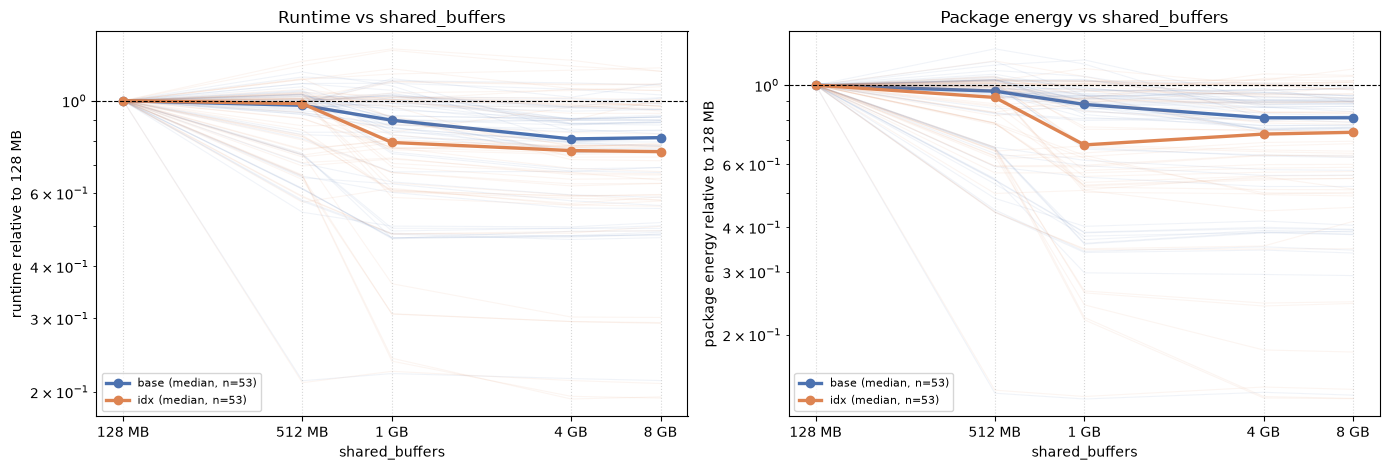

Total runtime / energy across the common query set, by size:
index_status  sb_mb  total_runtime_s  total_energy_j  queries
        base    128            231.3          3685.1       53
        base    512            159.2          2234.1       53
        base   1024            141.2          1673.9       53
        base   4096            138.3          1629.6       53
        base   8192            140.8          1610.2       53
         idx    128             53.7          1084.6       53
         idx    512             39.5           814.0       53
         idx   1024             32.2           628.4       53
         idx   4096             30.1           576.3       53
         idx   8192             29.9           572.2       53
  [base] fastest total: 4 GB  |  lowest energy: 8 GB
  [idx] fastest total: 8 GB  |  lowest energy: 8 GB


In [5]:
def relative(metric, ix):
    # use only the sizes this variant covers broadly, so an incomplete size
    # (e.g. idx @ 4 GB with a single query) doesn't collapse the whole line
    sub = data[data["index_status"] == ix]
    cov = sub.groupby("sb_mb")["qid"].nunique()
    good = [m for m in SB_ALL if cov.get(m, 0) >= 0.5 * cov.max()]
    piv = sub.pivot_table(index="qid", columns="sb_mb", values=metric).reindex(columns=good)
    piv = piv.dropna(how="any")
    rel = piv.div(piv[good[0]], axis=0) if not piv.empty else piv
    return good, piv, rel


fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
for ax, metric, nice in ((axes[0], "avg_time_s", "runtime"),
                         (axes[1], "avg_pkg_j", "package energy")):
    for ix in IDX_ALL:
        good, piv, rel = relative(metric, ix)
        if rel.empty:
            continue
        for _, row in rel.iterrows():
            ax.plot(good, row.values, color=colours[ix], alpha=0.08, lw=0.8)
        ax.plot(good, rel.median().values, color=colours[ix], marker="o",
                lw=2.4, label=f"{ix} (median, n={len(rel)})")
    ax.axhline(1.0, color="k", lw=0.8, ls="--")
    ax.set_xscale("log", base=2); ax.set_yscale("log")
    ax.set_xticks(SB_ALL); ax.set_xticklabels([sb_label(m) for m in SB_ALL])
    ax.set_xlabel("shared_buffers")
    ax.set_ylabel(f"{nice} relative to {sb_label(SB_ALL[0])}")
    ax.set_title(f"{nice.capitalize()} vs shared_buffers"); ax.grid(linestyle=":", alpha=0.5)
    ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

tot = data.groupby(["index_status", "sb_mb"]).agg(
    total_runtime_s=("avg_time_s", "sum"),
    total_energy_j=("avg_pkg_j", "sum"),
    queries=("qid", "nunique")).reset_index()
print("Total runtime / energy across the common query set, by size:")
print(tot.round(1).to_string(index=False))
for ix in IDX_ALL:
    t = tot[tot["index_status"] == ix].set_index("sb_mb")
    bt = t["total_runtime_s"].idxmin(); be = t["total_energy_j"].idxmin()
    print(f"  [{ix}] fastest total: {sb_label(bt)}  |  lowest energy: {sb_label(be)}")

## 6. Best shared_buffers per query — by runtime

Not every query wants the biggest cache — tiny queries are flat, and past the
working-set size more memory does nothing. For each query (base) we pick the
buffer size with the lowest runtime (needing a margin over the runner-up to
count, else it is a **tie / flat**) and tally how many queries prefer each size.

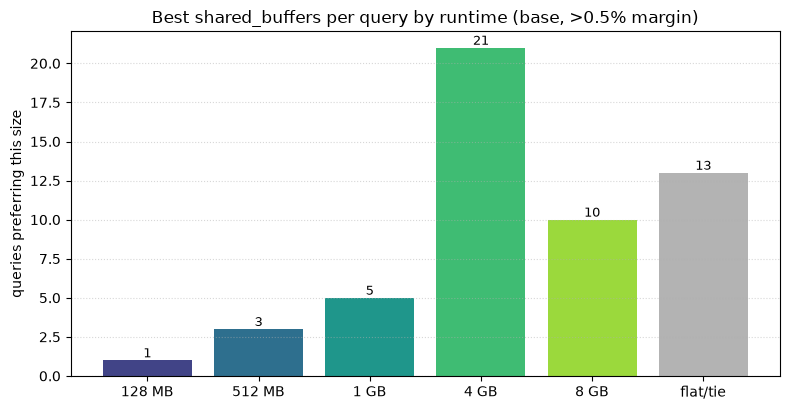

13/53 queries are flat (no size wins by >0.5%).

Queries that most want the largest cache (base, speedup 128 MB -> 8 GB):
qid
q13/v2_correlated.sql      4.70
q05/v1_materialized.sql    2.13
q08/base.sql               2.11
q05/base.sql               2.09
q08/v2_filter.sql          2.09
q08/v1_materialized.sql    2.07
q07/v1_materialized.sql    2.05
q07/base.sql               2.03
q07/v2_union_all.sql       2.00
q02/base.sql               1.96


In [6]:
MARGIN_PCT = 0.5     # must beat the next size by >this % to "prefer" it

base = data[data["index_status"] == "base"]
rt = base.pivot_table(index="qid", columns="sb_mb", values="avg_time_s").reindex(columns=SB_ALL)
rt = rt.dropna(how="any")
thr = 1 + MARGIN_PCT / 100.0
arr = rt.to_numpy()
order = np.argsort(arr, axis=1)
rows = np.arange(len(arr))
best = arr[rows, order[:, 0]]; runner = arr[rows, order[:, 1]]
winner = np.where(runner > best * thr,
                  np.array(SB_ALL)[order[:, 0]].astype(object), "flat/tie")
pref = pd.Series(winner, index=rt.index)
counts = pref.value_counts()

labels = [sb_label(m) for m in SB_ALL] + ["flat/tie"]
vals = [int(counts.get(m, 0)) for m in SB_ALL] + [int(counts.get("flat/tie", 0))]
fig, ax = plt.subplots(figsize=(8, 4.2))
bars = ax.bar(range(len(labels)), vals,
              color=list(plt.cm.viridis(np.linspace(0.2, 0.85, len(SB_ALL)))) + [(0.7, 0.7, 0.7, 1)])
for i, v in enumerate(vals):
    ax.text(i, v, str(v), ha="center", va="bottom", fontsize=9)
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels)
ax.set_ylabel("queries preferring this size")
ax.set_title(f"Best shared_buffers per query by runtime (base, >{MARGIN_PCT:g}% margin)")
ax.grid(axis="y", linestyle=":", alpha=0.5)
fig.tight_layout(); plt.show()

print(f"{int((pref == 'flat/tie').sum())}/{len(pref)} queries are flat "
      f"(no size wins by >{MARGIN_PCT:g}%).")
big = pref[pref == sb_label(SB_ALL[-1])] if False else None
print("\nQueries that most want the largest cache (base, "
      f"speedup {sb_label(SB_ALL[0])} -> {sb_label(SB_ALL[-1])}):")
speed = (rt[SB_ALL[0]] / rt[SB_ALL[-1]]).sort_values(ascending=False)
print(speed.head(10).round(2).to_string())

## 6b. Full ranking by runtime — how every size places across queries

Section 6 counted only each query's *winner*. This ranks **all** sizes per
query into 1st / 2nd / 3rd / … place (base runtimes) with the same
`MARGIN_PCT`: sizes within that margin of a place's best **share** that place
(so two near-identical sizes can both be "1st", and the next distinct size is
"2nd"). Every bar therefore totals the query count, coloured by the place that
size took — a mostly-green size (usually 1st) is the safe default; lots of red
means it is usually the worst choice.

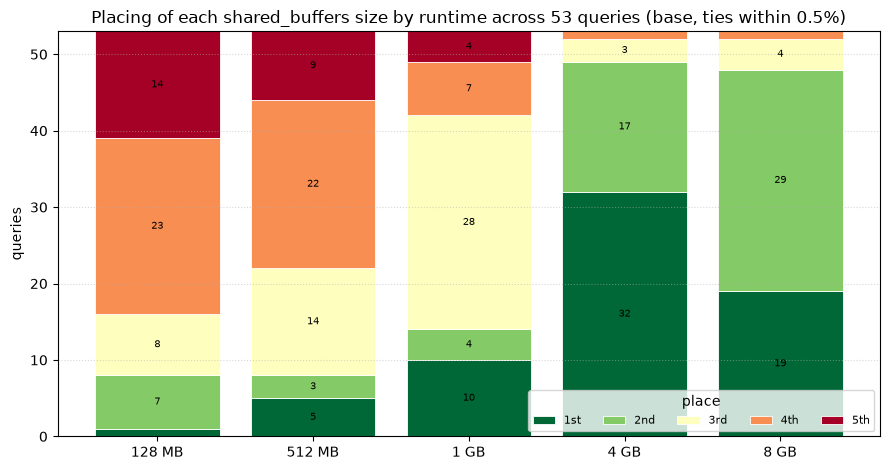

Placings across 53 queries (ties within 0.5% share a place):
        1st  2nd  3rd  4th  5th
128 MB    1    7    8   23   14
512 MB    5    3   14   22    9
1 GB     10    4   28    7    4
4 GB     32   17    3    1    0
8 GB     19   29    4    1    0


In [7]:
MARGIN_PCT = 0.5     # sizes within this % of a place's best share that place

base = data[data["index_status"] == "base"]
rt = base.pivot_table(index="qid", columns="sb_mb", values="avg_time_s").reindex(columns=SB_ALL)
rt = rt.dropna(how="any")


def positions(row):
    # sort sizes fastest-first; a size shares the current place if it is within
    # MARGIN_PCT of that place's best, otherwise it starts the next place.
    place, gbest = 0, None
    out = {}
    for m in sorted(SB_ALL, key=lambda k: row[k]):
        if gbest is None or row[m] > gbest * (1 + MARGIN_PCT / 100.0):
            place += 1
            gbest = row[m]
        out[m] = place
    return pd.Series(out)


posdf = rt.apply(positions, axis=1)          # qid x sb_mb -> place (1..)
maxpos = int(posdf.to_numpy().max())
counts = {m: posdf[m].value_counts() for m in SB_ALL}


def ordinal(k):
    return {1: "1st", 2: "2nd", 3: "3rd"}.get(k, f"{k}th")


def place_colour(p):
    # 1st = green, last = red
    frac = 1.0 if maxpos == 1 else (maxpos - p) / (maxpos - 1)
    return plt.cm.RdYlGn(frac)


fig, ax = plt.subplots(figsize=(9, 4.8))
x = np.arange(len(SB_ALL))
bottom = np.zeros(len(SB_ALL))
for p in range(1, maxpos + 1):
    vals = np.array([int(counts[m].get(p, 0)) for m in SB_ALL], dtype=float)
    ax.bar(x, vals, bottom=bottom, color=place_colour(p), label=ordinal(p),
           edgecolor="white", linewidth=0.6)
    for xi, (v, b) in enumerate(zip(vals, bottom)):
        if v >= 2:
            ax.text(xi, b + v / 2, int(v), ha="center", va="center", fontsize=7)
    bottom += vals
ax.set_xticks(x); ax.set_xticklabels([sb_label(m) for m in SB_ALL])
ax.set_ylabel("queries")
ax.set_title(f"Placing of each shared_buffers size by runtime across {len(rt)} queries "
             f"(base, ties within {MARGIN_PCT:g}%)")
ax.legend(title="place", fontsize=8, ncol=maxpos)
ax.grid(axis="y", linestyle=":", alpha=0.5)
fig.tight_layout(); plt.show()
fig.savefig("sb_placing.png", dpi=300, bbox_inches="tight")

summary = pd.DataFrame(
    {ordinal(p): [int(counts[m].get(p, 0)) for m in SB_ALL]
     for p in range(1, maxpos + 1)},
    index=[sb_label(m) for m in SB_ALL])
print(f"Placings across {len(rt)} queries (ties within {MARGIN_PCT:g}% share a place):")
print(summary.to_string())

## 6c. Best shared_buffers per query — by energy

The same tally as §6, but ranking each query's sizes by **package energy**
(`avg_pkg_j`) instead of runtime. Since energy = power × time and power is not
constant across sizes, the lowest-energy size can differ from the fastest one.

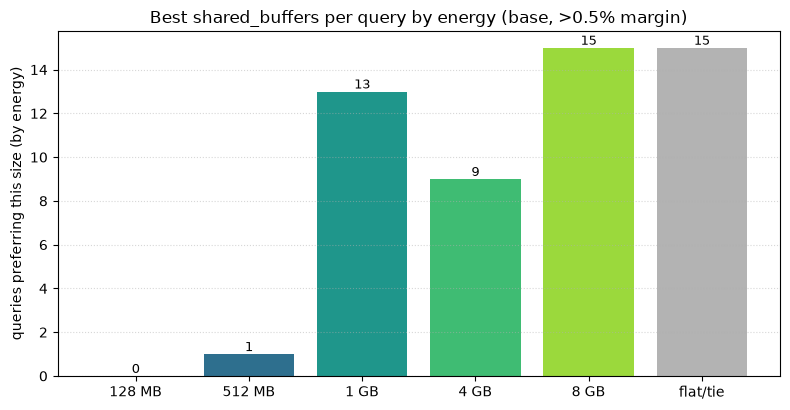

15/53 queries are flat on energy (no size wins by >0.5%).

Queries whose energy drops most with the largest cache (base, energy ratio 128 MB -> 8 GB):
qid
q13/v2_correlated.sql      7.38
q02/base.sql               3.41
q05/base.sql               2.95
q05/v1_materialized.sql    2.90
q07/v2_union_all.sql       2.62
q07/base.sql               2.61
q07/v1_materialized.sql    2.58
q08/base.sql               2.57
q08/v1_materialized.sql    2.54
q08/v2_filter.sql          2.53


In [8]:
MARGIN_PCT = 0.5     # must beat the next size by >this % to "prefer" it

base = data[data["index_status"] == "base"]
en = base.pivot_table(index="qid", columns="sb_mb", values="avg_pkg_j").reindex(columns=SB_ALL)
en = en.dropna(how="any")
thr = 1 + MARGIN_PCT / 100.0
arr = en.to_numpy()
order = np.argsort(arr, axis=1)
rows = np.arange(len(arr))
best = arr[rows, order[:, 0]]; runner = arr[rows, order[:, 1]]
winner = np.where(runner > best * thr,
                  np.array(SB_ALL)[order[:, 0]].astype(object), "flat/tie")
pref = pd.Series(winner, index=en.index)
counts = pref.value_counts()

labels = [sb_label(m) for m in SB_ALL] + ["flat/tie"]
vals = [int(counts.get(m, 0)) for m in SB_ALL] + [int(counts.get("flat/tie", 0))]
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.bar(range(len(labels)), vals,
       color=list(plt.cm.viridis(np.linspace(0.2, 0.85, len(SB_ALL)))) + [(0.7, 0.7, 0.7, 1)])
for i, v in enumerate(vals):
    ax.text(i, v, str(v), ha="center", va="bottom", fontsize=9)
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels)
ax.set_ylabel("queries preferring this size (by energy)")
ax.set_title(f"Best shared_buffers per query by energy (base, >{MARGIN_PCT:g}% margin)")
ax.grid(axis="y", linestyle=":", alpha=0.5)
fig.tight_layout(); plt.show()

print(f"{int((pref == 'flat/tie').sum())}/{len(pref)} queries are flat on energy "
      f"(no size wins by >{MARGIN_PCT:g}%).")
print("\nQueries whose energy drops most with the largest cache (base, "
      f"energy ratio {sb_label(SB_ALL[0])} -> {sb_label(SB_ALL[-1])}):")
esave = (en[SB_ALL[0]] / en[SB_ALL[-1]]).sort_values(ascending=False)
print(esave.head(10).round(2).to_string())

## 6d. Full ranking by energy — how every size places across queries

The §6b placings, but ranking all sizes per query by **package energy** rather
than runtime. Compare the colours against §6b: a size that usually wins on
runtime but not on energy (or vice-versa) exposes a time-vs-energy trade-off.

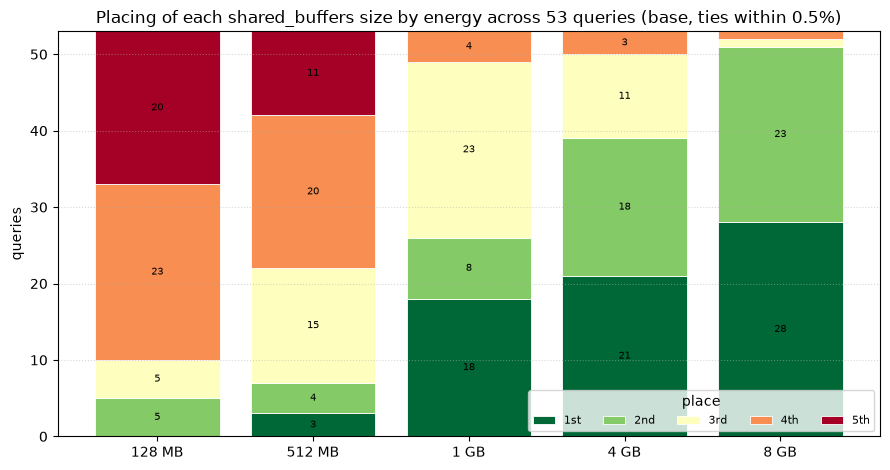

Energy placings across 53 queries (ties within 0.5% share a place):
        1st  2nd  3rd  4th  5th
128 MB    0    5    5   23   20
512 MB    3    4   15   20   11
1 GB     18    8   23    4    0
4 GB     21   18   11    3    0
8 GB     28   23    1    1    0


In [11]:
MARGIN_PCT = 0.5     # sizes within this % of a place's best share that place

base = data[data["index_status"] == "base"]
en = base.pivot_table(index="qid", columns="sb_mb", values="avg_pkg_j").reindex(columns=SB_ALL)
en = en.dropna(how="any")


def positions(row):
    place, gbest = 0, None
    out = {}
    for m in sorted(SB_ALL, key=lambda k: row[k]):
        if gbest is None or row[m] > gbest * (1 + MARGIN_PCT / 100.0):
            place += 1
            gbest = row[m]
        out[m] = place
    return pd.Series(out)


posdf = en.apply(positions, axis=1)          # qid x sb_mb -> place (1..)
maxpos = int(posdf.to_numpy().max())
counts = {m: posdf[m].value_counts() for m in SB_ALL}


def ordinal(k):
    return {1: "1st", 2: "2nd", 3: "3rd"}.get(k, f"{k}th")


def place_colour(p):
    frac = 1.0 if maxpos == 1 else (maxpos - p) / (maxpos - 1)
    return plt.cm.RdYlGn(frac)


fig, ax = plt.subplots(figsize=(9, 4.8))
x = np.arange(len(SB_ALL))
bottom = np.zeros(len(SB_ALL))
for p in range(1, maxpos + 1):
    vals = np.array([int(counts[m].get(p, 0)) for m in SB_ALL], dtype=float)
    ax.bar(x, vals, bottom=bottom, color=place_colour(p), label=ordinal(p),
           edgecolor="white", linewidth=0.6)
    for xi, (v, b) in enumerate(zip(vals, bottom)):
        if v >= 2:
            ax.text(xi, b + v / 2, int(v), ha="center", va="center", fontsize=7)
    bottom += vals
ax.set_xticks(x); ax.set_xticklabels([sb_label(m) for m in SB_ALL])
ax.set_ylabel("queries")
ax.set_title(f"Placing of each shared_buffers size by energy across {len(en)} queries "
             f"(base, ties within {MARGIN_PCT:g}%)")
ax.legend(title="place", fontsize=8, ncol=maxpos)
ax.grid(axis="y", linestyle=":", alpha=0.5)
fig.tight_layout(); plt.show()
fig.savefig("sb_placing_energy.png", dpi=300, bbox_inches="tight")

summary = pd.DataFrame(
    {ordinal(p): [int(counts[m].get(p, 0)) for m in SB_ALL]
     for p in range(1, maxpos + 1)},
    index=[sb_label(m) for m in SB_ALL])
print(f"Energy placings across {len(en)} queries (ties within {MARGIN_PCT:g}% share a place):")
print(summary.to_string())

## 7. Indexing vs buffering — which lever matters more?

Two ways to make a query faster: give it more buffer cache, or give it an
index. This compares, per query, the **buffering speedup** (base runtime at the
smallest vs largest `shared_buffers`) against the **indexing speedup** (base vs
indexed at a fixed, common size). Points above the diagonal are helped more by
an index; points to the right are helped more by buffers.

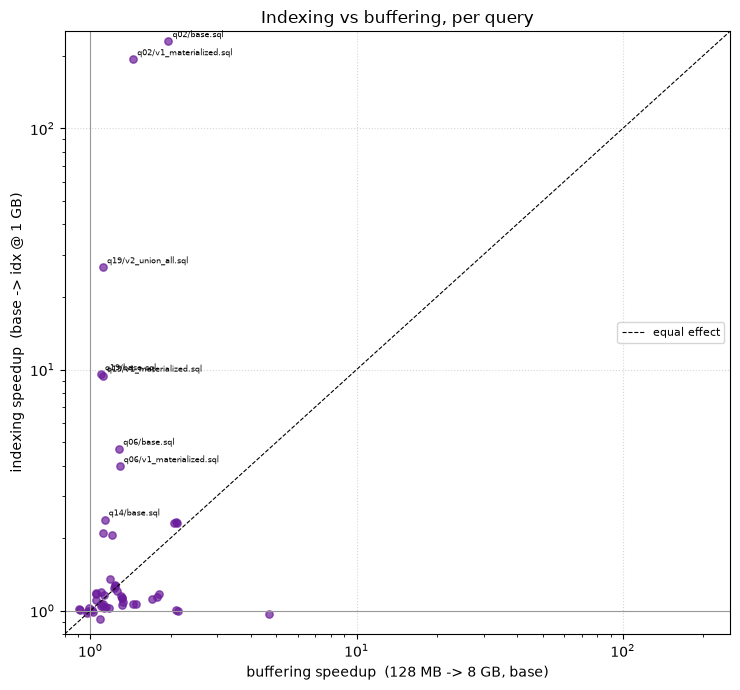

At 1 GB: indexing beats buffering for 27/53 queries; buffering wins for 26.
median buffering speedup: 1.23x; median indexing speedup: 1.13x


In [10]:
common_sb = [m for m in SB_ALL
             if {"base", "idx"} <= set(data.loc[data["sb_mb"] == m, "index_status"])]
if not common_sb:
    print("No shared_buffers size has both base and indexed runs - "
          "cannot compare indexing vs buffering yet.")
else:
    fix = common_sb[len(common_sb) // 2]           # a middle common size
    base = data[data["index_status"] == "base"]
    rt = base.pivot_table(index="qid", columns="sb_mb", values="avg_time_s").reindex(columns=SB_ALL)
    buffering = (rt[SB_ALL[0]] / rt[SB_ALL[-1]]).rename("buffering_x")

    bt = data[(data["index_status"] == "base") & (data["sb_mb"] == fix)].set_index("qid")["avg_time_s"]
    it = data[(data["index_status"] == "idx") & (data["sb_mb"] == fix)].set_index("qid")["avg_time_s"]
    indexing = (bt / it).rename("indexing_x")

    comp = pd.concat([buffering, indexing], axis=1).dropna()
    comp = comp[(comp["buffering_x"] > 0) & (comp["indexing_x"] > 0)]
    fig, ax = plt.subplots(figsize=(7.5, 7))
    ax.scatter(comp["buffering_x"], comp["indexing_x"], s=28, alpha=0.7, color="#6a1b9a")
    lim = [0.8, max(3.0, comp.to_numpy().max() * 1.1)]
    ax.plot(lim, lim, color="k", lw=0.8, ls="--", label="equal effect")
    ax.axhline(1, color="0.6", lw=0.8); ax.axvline(1, color="0.6", lw=0.8)
    for q, row in comp.sort_values(["indexing_x", "buffering_x"]).tail(8).iterrows():
        ax.annotate(q, (row["buffering_x"], row["indexing_x"]), fontsize=6,
                    xytext=(3, 3), textcoords="offset points")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel(f"buffering speedup  ({sb_label(SB_ALL[0])} -> {sb_label(SB_ALL[-1])}, base)")
    ax.set_ylabel(f"indexing speedup  (base -> idx @ {sb_label(fix)})")
    ax.set_title("Indexing vs buffering, per query")
    ax.legend(fontsize=8); ax.grid(linestyle=":", alpha=0.5)
    fig.tight_layout(); plt.show()

    idx_wins = int((comp["indexing_x"] > comp["buffering_x"]).sum())
    print(f"At {sb_label(fix)}: indexing beats buffering for {idx_wins}/{len(comp)} "
          f"queries; buffering wins for {len(comp) - idx_wins}.")
    print(f"median buffering speedup: {comp['buffering_x'].median():.2f}x; "
          f"median indexing speedup: {comp['indexing_x'].median():.2f}x")